### Problem Statement


X Education organization conducts the online training courses. Their marketing team collecting the leads of potential clients / students who are approaching their communication channels from different sources. Sale team approach potential leads and propose to take up the course. As per the X Educational trend, indicating that only around 30% students are boarding. To make a process more effective company wanted to identify hot leads if this is achieved sales team can focused in concentrating to board hot leads, which will subsequently increase the on boarding.

### Business Objective 

- Predict the Lead Score betwen 0 and 100 based on the historical information with certain depnedent variables.

###  Approach
- Understand the provided data 
- Processing data cleaning and creating necessessory derived variables
- Split data for testing and training 
- Prepare data for Model readiness 
- Model implementation 
- Model Validations 
- Model verification on test data 
- Final recommendations 


In [104]:
# Importing required libraries

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 500)
%matplotlib inline 

# Modeling tools
from sklearn.model_selection import train_test_split
import statsmodels 
import statsmodels.api as sm
from sklearn.feature_selection import RFE
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression

#Metrics 
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


#Scaling Libabries 
from sklearn.preprocessing import StandardScaler




from IPython.display import Markdown, display
def printmd(string):
    display(Markdown(string))
    
# Source Data file is located 

Source_data =f"Data\\Leads.csv"

In [105]:
# Importing Required data 

ds_data = pd.read_csv(Source_data)

printmd(f"Shape of Source Data <b> { ds_data.shape} </b>")

ds_data.info()

Shape of Source Data <b> (9240, 37) </b>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
Prospect ID                                      9240 non-null object
Lead Number                                      9240 non-null int64
Lead Origin                                      9240 non-null object
Lead Source                                      9204 non-null object
Do Not Email                                     9240 non-null object
Do Not Call                                      9240 non-null object
Converted                                        9240 non-null int64
TotalVisits                                      9103 non-null float64
Total Time Spent on Website                      9240 non-null int64
Page Views Per Visit                             9103 non-null float64
Last Activity                                    9137 non-null object
Country                                          6779 non-null object
Specialization                                   7802 

### Review Remaks 

- Observed that there are 

In [106]:
# verify if any duplicates in data set 

ds_data[ds_data.duplicated()]

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity


### Review Renmaks 

No duplicates found

In [107]:
## It is indicates that  Prospect ID /  Lead_number is not a usefull for preduction these are seems system generated unique numbers 
Original_data=ds_data.copy()
ds_data=ds_data.drop(["Prospect ID","Lead Number"],axis=1)

# rearanging column names
ds_data.columns =ds_data.columns.str.replace(" ","_")

ds_data.head()

,Lead_Origin,Lead_Source,Do_Not_Email,Do_Not_Call,Converted,TotalVisits,Total_Time_Spent_on_Website,Page_Views_Per_Visit,Last_Activity,Country,Specialization,How_did_you_hear_about_X_Education,What_is_your_current_occupation,What_matters_most_to_you_in_choosing_a_course,Search,Magazine,Newspaper_Article,X_Education_Forums,Newspaper,Digital_Advertisement,Through_Recommendations,Receive_More_Updates_About_Our_Courses,Tags,Lead_Quality,Update_me_on_Supply_Chain_Content,Get_updates_on_DM_Content,Lead_Profile,City,Asymmetrique_Activity_Index,Asymmetrique_Profile_Index,Asymmetrique_Activity_Score,Asymmetrique_Profile_Score,I_agree_to_pay_the_amount_through_cheque,A_free_copy_of_Mastering_The_Interview,Last_Notable_Activity
0,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,NaN,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,NaN,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,Select,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,Not Sure,No,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,Select,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [108]:
## Select column

# as per the problem statement application specific defualt values such as variables with the "Select" can be considered as NULL

ds_data=ds_data.replace('Select', np.nan)

In [109]:
### Understand the null Variables 

_temp = pd.DataFrame ((ds_data.isnull().sum(axis=0) / ds_data.shape[0]).round(4))
_temp.columns=["Per_Missing"]
_temp["Per_Missing"] =_temp["Per_Missing"] *100
_temp["col_types"] = ds_data[_temp.index].dtypes
_temp[_temp.Per_Missing != 0].sort_values(by="Per_Missing",ascending =False)   


,Per_Missing,col_types
How_did_you_hear_about_X_Education,78.46,object
Lead_Profile,74.19,object
Lead_Quality,51.59,object
Asymmetrique_Profile_Score,45.65,float64
Asymmetrique_Activity_Score,45.65,float64
Asymmetrique_Profile_Index,45.65,object
Asymmetrique_Activity_Index,45.65,object
City,39.71,object
Specialization,36.58,object
Tags,36.29,object


### Review Comments 

-- indicating around 13 variables having missing values over 20% and only about the 4 variables indicating missing values lesser than 2%

- Approch 

    - Since most of missing values were categorical columns, we will evaluate what are the options left out for each variable to impute.
    - Better to understand what is the each value represent how to treat. if categorical column is having null value we may go for one hot encoding with ingorence of NA's
    - Lead profile is also indicating derived field from the profiling done by the sale agent. to optmize sale staff work our objective is to increase the prductivity hences this field will be useless

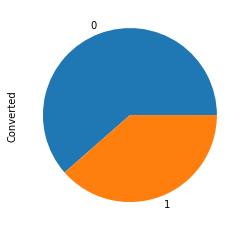

,Converted
0,5679
1,3561


In [110]:
# Target Variable visualization 

ds_data.Converted.value_counts().plot(kind="pie")
plt.show()

pd.DataFrame(ds_data.Converted.value_counts())

### Review Comments 

Indicating that around 39% of target leads are converted

In [111]:
# below fields indicating end result of profiling done by the sales staff manually. our objctive is to identify the hot leads without manual verification in that case these properies will be useless

ds_data=ds_data.drop("Lead_Profile",axis=1)
ds_data=ds_data.drop("Lead_Quality",axis=1)

#### Total Missing Values for How_did_you_hear_about_X_Education is <font color='red'> 7250 </font>

Eqlaing to <font> color ='red'>78.46% </font>

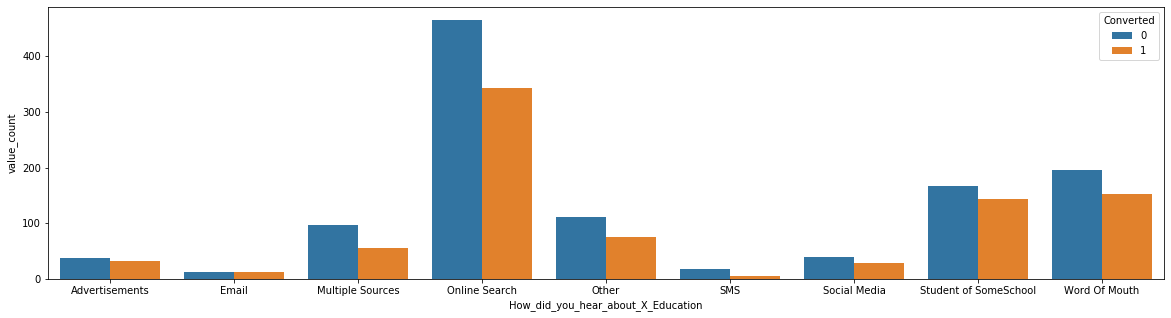

In [112]:
## Observ the How_did_you_hear_about_X_Education

_temp = pd.DataFrame(ds_data.groupby(["How_did_you_hear_about_X_Education","Converted"])["Converted"].count())

_temp.columns=["value_count"]
_temp.reset_index(inplace = True)

printmd(f"#### Total Missing Values for How_did_you_hear_about_X_Education is <font color='red'> {ds_data.How_did_you_hear_about_X_Education.isna().sum()} </font>")
printmd(f"Eqlaing to <font> color ='red'>{(ds_data.How_did_you_hear_about_X_Education.isna().sum() / ds_data.shape[0]).round(4)*100}% </font>")

plt.figure(figsize=(20,5))
sns.barplot(data=_temp,x="How_did_you_hear_about_X_Education",y="value_count",hue="Converted")
plt.show()
#_temp

###  Review Remaks 

By seeing the data information provided through How_did_you_hear_about_X_Education 78% of missing values at the same time it is not indicating any expandability of target variable in that case we can delete this column   

In [113]:
ds_data=ds_data.drop("How_did_you_hear_about_X_Education",axis=1)

Missing Values for Asymmetrique_Profile_Index  : <font color ='red'> 45.65% </font>

Missing Values for Asymmetrique_Activity_Index  : <font color ='red'> 45.65%  </font>

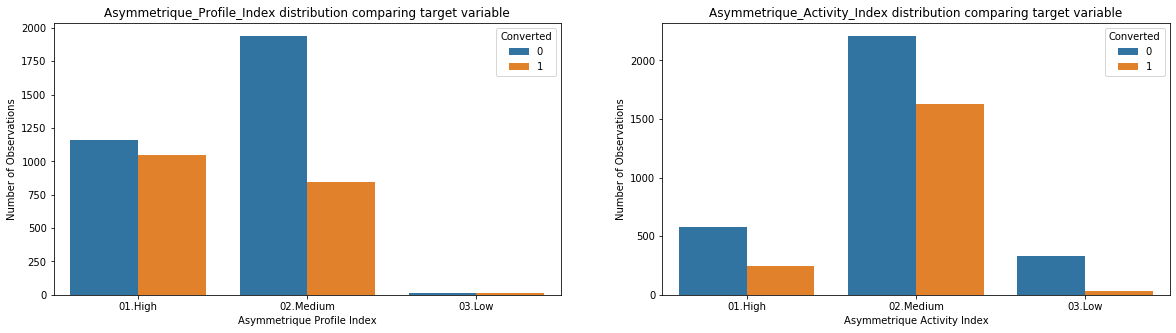

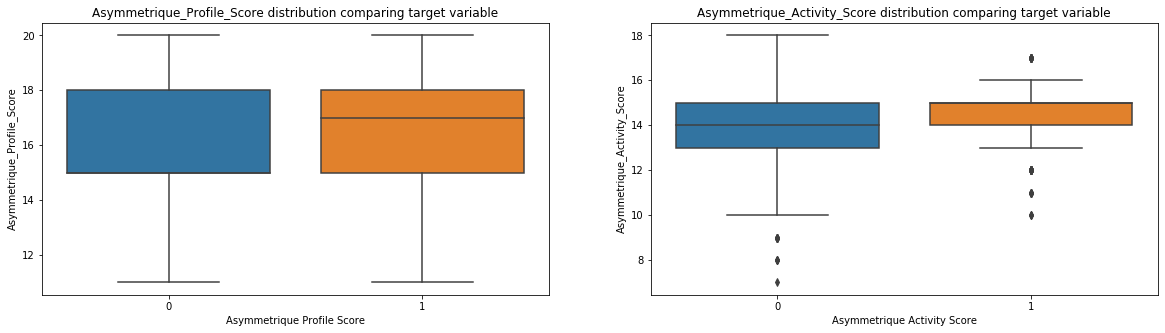

In [114]:
# study As Asymmetrique properties 


#ds_data[['Asymmetrique_Profile_Score','Asymmetrique_Activity_Score','Asymmetrique_Profile_Index','Asymmetrique_Activity_Index']]

def display_relation_graph(x,ind):
    
    _temp = pd.DataFrame(ds_data.groupby([x,"Converted"])["Converted"].count())
    _temp.columns=["value_count"]
    _temp.reset_index(inplace = True)
    plt.subplot(1,2,ind)
    sns.barplot(data=_temp,x=x,y="value_count",hue="Converted")
    plt.title(f"{x} distribution comparing target variable")
    plt.xlabel(x.replace("_"," "))
    plt.ylabel("Number of Observations")
    
    
printmd(f"Missing Values for Asymmetrique_Profile_Index  : <font color ='red'> {(ds_data.Asymmetrique_Profile_Index.isnull().sum() / ds_data.shape[0]).round(4) *100}% </font>")
printmd(f"Missing Values for Asymmetrique_Activity_Index  : <font color ='red'> {(ds_data.Asymmetrique_Activity_Index.isnull().sum() / ds_data.shape[0]).round(4) * 100}%  </font>")
plt.figure(figsize=(20,5))
display_relation_graph("Asymmetrique_Profile_Index",1)
display_relation_graph("Asymmetrique_Activity_Index",2)
plt.show()


def display_box_plot(x,ind):
    plt.subplot(1,2,ind)
    sns.boxplot(data=ds_data,y=x,x="Converted")
    plt.title(f"{x} distribution comparing target variable")
    plt.xlabel(x.replace("_"," "))
    
plt.figure(figsize=(20,5))
display_box_plot("Asymmetrique_Profile_Score",1)
display_box_plot("Asymmetrique_Activity_Score",2)
plt.show()


### Review Remaks 

- 45% are missing values for all the Asymmetrique_Profile_Score, Asymmetrique_Activity_Score, Asymmetrique_Profile_Index, Asymmetrique_Activity_Index
- all the above coloumns indicating like derived fields based on the profiles of the customer by the platform itself. however no much +Ve varience comparing with the target variable hence it is recomended to delete these variables

In [115]:
# Delete unreasonable variables Asymmetrique_Profile_Score, Asymmetrique_Activity_Score, Asymmetrique_Profile_Index, Asymmetrique_Activity_Index


ds_data=ds_data.drop(["Asymmetrique_Profile_Score","Asymmetrique_Activity_Score","Asymmetrique_Profile_Index","Asymmetrique_Activity_Index"],axis=1)

#### Total Missing Values for City is <font color='red'> 3669 </font>

Eqlaing to <font> color ='red'>39.71% </font>

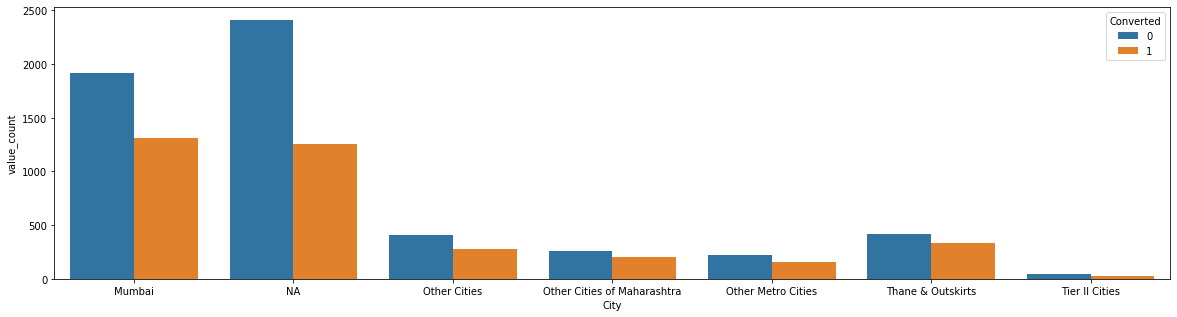

value_count                                                 \
City           Mumbai    NA Other Cities Other Cities of Maharashtra   
Converted                                                              
0                1913  2412          410                         256   
1                1309  1257          276                         201   
All              3222  3669          686                         457   

                                                                     
City      Other Metro Cities Thane & Outskirts Tier II Cities   All  
Converted                                                            
0                        225               414             49  5679  
1                        155               338             25  3561  
All                      380               752             74  9240

In [116]:
_temp = pd.DataFrame(ds_data[["City","Converted"]].fillna("NA").groupby(["City","Converted"])["Converted"].count())

_temp.columns=["value_count"]
_temp.reset_index(inplace = True)

printmd(f"#### Total Missing Values for City is <font color='red'> {ds_data.City.isna().sum()} </font>")
printmd(f"Eqlaing to <font> color ='red'>{(ds_data.City.isna().sum() / ds_data.shape[0]).round(4)*100}% </font>")

plt.figure(figsize=(20,5))
sns.barplot(data=_temp,x="City",y="value_count",hue="Converted")
plt.show()

_temp = pd.pivot_table(data=_temp,index=["Converted"],values=["value_count"],columns=["City"],aggfunc = "sum",margins=True).round()
_temp

## Review Remaks 

- Based on the above, it indicates that 39% of values are missing
- all these profiles seems belongs to the Maharastra region 
- indictaing that missing values were also similar proposition with target variable

- based on the above fact it is desided to impute the city field with Mumbai where ever missing

In [117]:
# imputing  City Variable with Mumbai 

ds_data.City =ds_data.City.fillna("Mumbai")

#### Total Missing Values for Specialization is <font color='red'> 3380 </font>

Eqlaing to <font color ='red'>36.58% </font>

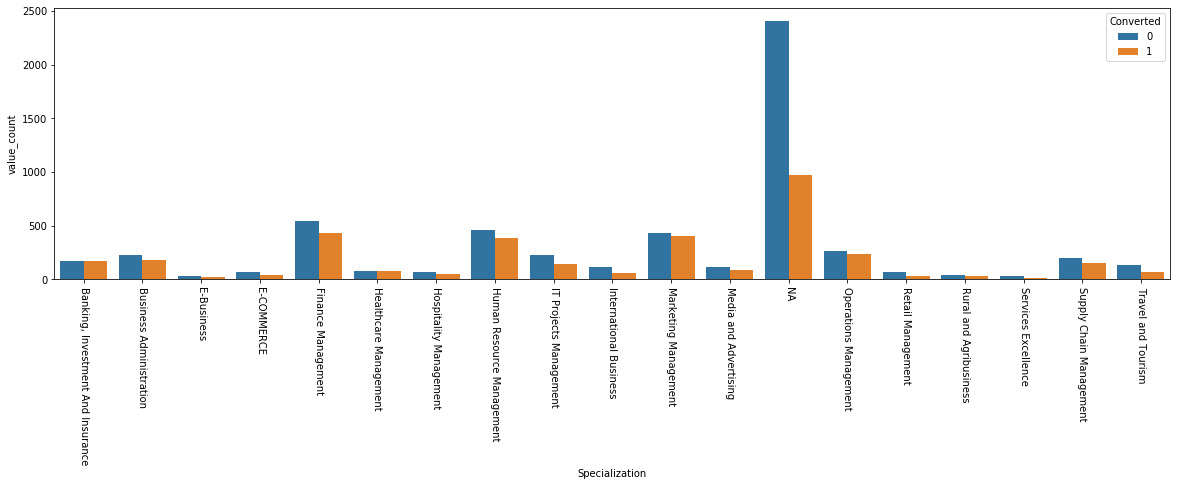

value_count            
Converted                                   0     1   All
Specialization                                           
Banking, Investment And Insurance         171   167   338
Business Administration                   224   179   403
E-Business                                 36    21    57
E-COMMERCE                                 72    40   112
Finance Management                        540   436   976
Healthcare Management                      80    79   159
Hospitality Management                     66    48   114
Human Resource Management                 460   388   848
IT Projects Management                    226   140   366
International Business                    114    64   178
Marketing Management                      430   408   838
Media and Advertising                     118    85   203
NA                                       2411   969  3380
Operations Management                     265   238   503
Retail Management                          66    34   100
Rural and Agribusiness                     42    31    73
Services Excellence                        29    11    40
Supply Chain Management                   198   151   349
Travel and Tourism                        131    72   203
All                                      5679  3561  9240

In [118]:
# Analyse the Specialization field

_temp = pd.DataFrame(ds_data[["Specialization","Converted"]].fillna("NA").groupby(["Specialization","Converted"])["Converted"].count())

_temp.columns=["value_count"]
_temp.reset_index(inplace = True)

printmd(f"#### Total Missing Values for Specialization is <font color='red'> {ds_data.Specialization.isna().sum()} </font>")
printmd(f"Eqlaing to <font color ='red'>{(ds_data.Specialization.isna().sum() / ds_data.shape[0]).round(4)*100}% </font>")

plt.figure(figsize=(20,5))
ax=sns.barplot(data=_temp,x="Specialization",y="value_count",hue="Converted")
plt.xticks(rotation=270)
plt.show()

_temp = pd.pivot_table(data=_temp,index=["Specialization"],values=["value_count"],columns=["Converted"],aggfunc = "sum",margins=True).round()
_temp

### Review Remaks

- around 36% of values are missing.
- not found any depending trend with the target variables 

- decisded to fill with Others

In [119]:
# imputed Specialization values
ds_data.Specialization  = ds_data.Specialization.fillna("Others")

#### Total Missing Values for Tags is <font color='red'> 3353 </font>

Eqlaing to <font color ='red'>36.29% </font>

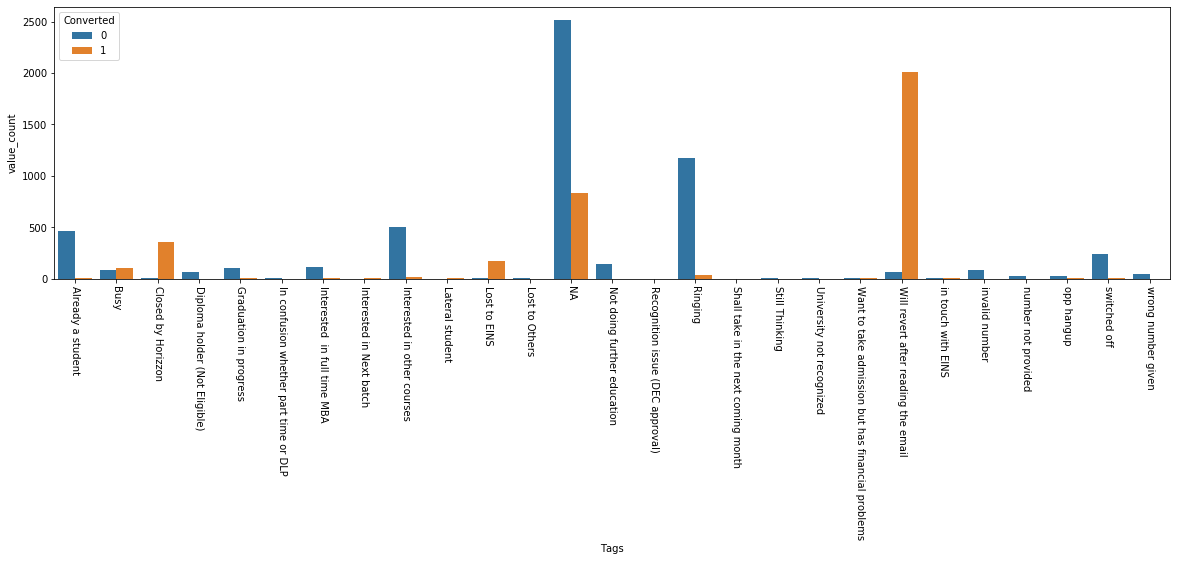

value_count              
Converted                                                   0       1   All
Tags                                                                       
Already a student                                       462.0     3.0   465
Busy                                                     81.0   105.0   186
Closed by Horizzon                                        2.0   356.0   358
Diploma holder (Not Eligible)                            62.0     1.0    63
Graduation in progress                                  104.0     7.0   111
In confusion whether part time or DLP                     4.0     1.0     5
Interested  in full time MBA                            114.0     3.0   117
Interested in Next batch                                  NaN     5.0     5
Interested in other courses                             500.0    13.0   513
Lateral student                                           NaN     3.0     3
Lost to EINS                                              4.0   171.0   175
Lost to Others                                            7.0     NaN     7
NA                                                     2517.0   836.0  3353
Not doing further education                             144.0     1.0   145
Recognition issue (DEC approval)                          1.0     NaN     1
Ringing                                                1169.0    34.0  1203
Shall take in the next coming month                       1.0     1.0     2
Still Thinking                                            5.0     1.0     6
University not recognized                                 2.0     NaN     2
Want to take admission but has financial problems         4.0     2.0     6
Will revert after reading the email                      65.0  2007.0  2072
in touch with EINS                                        9.0     3.0    12
invalid number                                           82.0     1.0    83
number not provided                                      27.0     NaN    27
opp hangup                                               30.0     3.0    33
switched off                                            236.0     4.0   240
wrong number given                                       47.0     NaN    47
All                                                    5679.0  3561.0  9240

In [120]:
# Review the Tag Variable


_temp = pd.DataFrame(ds_data[["Tags","Converted"]].fillna("NA").groupby(["Tags","Converted"])["Converted"].count())

_temp.columns=["value_count"]
_temp.reset_index(inplace = True)

printmd(f"#### Total Missing Values for Tags is <font color='red'> {ds_data.Tags.isna().sum()} </font>")
printmd(f"Eqlaing to <font color ='red'>{(ds_data.Tags.isna().sum() / ds_data.shape[0]).round(4)*100}% </font>")

_temp =_temp.fillna(0)

plt.figure(figsize=(20,5))
ax=sns.barplot(data=_temp,x="Tags",y="value_count",hue="Converted")
plt.xticks(rotation=270)
plt.show()


_temp = pd.pivot_table(data=_temp,index=["Tags"],values=["value_count"],columns=["Converted"],aggfunc = "sum",margins=True).round()
_temp

# Review Remaks 

indicates that TAG field is look like most of profileing is done by the agents. the purpose of our model is to eleminate the work done by manually. hence it is desided to remove this column 


In [121]:
# drop tag columns 

ds_data =ds_data.drop("Tags",axis=1)

In [122]:
# review What_matters_most_to_you_in_choosing_a_course

ds_data.What_matters_most_to_you_in_choosing_a_course.fillna("NA").value_counts() / ds_data.shape[0]

Better Career Prospects      0.706494
NA                           0.293182
Flexibility & Convenience    0.000216
Other                        0.000108
Name: What_matters_most_to_you_in_choosing_a_course, dtype: float64

### Review Remaks

- What_matters_most_to_you_in_choosing_a_course indicates 70% of values on addressed as "Better Career Prospects" which indicates and remaining 29% are Blank in that case imputing this value seems useless hence decisded to remove 



In [123]:
# drop column What_matters_most_to_you_in_choosing_a_course

ds_data=ds_data.drop("What_matters_most_to_you_in_choosing_a_course",axis=1)

#### Total Missing Values for What_is_your_current_occupation is <font color='red'> 2690 </font>

Eqlaing to <font color ='red'>29.11% </font>

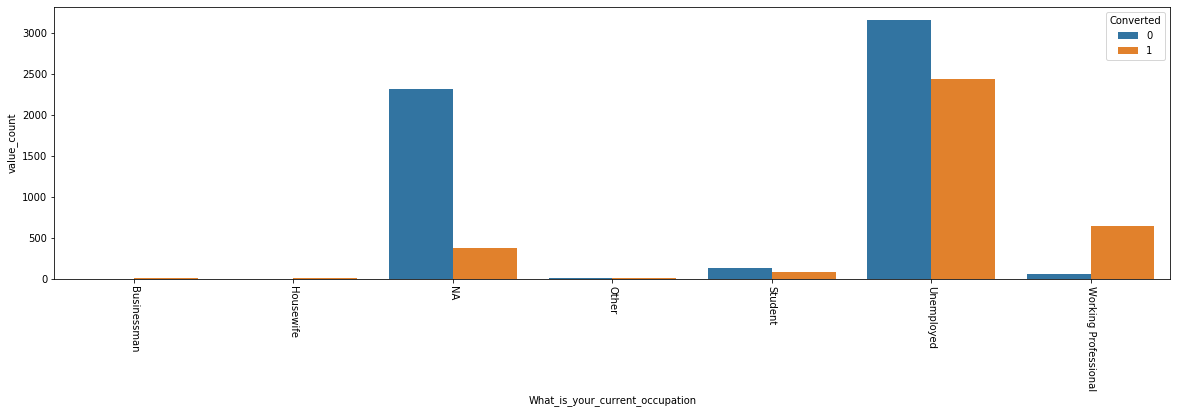

value_count              
Converted                                 0       1   All
What_is_your_current_occupation                          
Businessman                             3.0     5.0     8
Housewife                               NaN    10.0    10
NA                                   2320.0   370.0  2690
Other                                   6.0    10.0    16
Student                               132.0    78.0   210
Unemployed                           3159.0  2441.0  5600
Working Professional                   59.0   647.0   706
All                                  5679.0  3561.0  9240

In [124]:
# Review What_is_your_current_occupation

#pd.DataFrame(ds_data.What_is_your_current_occupation.fillna("NA").value_counts() / ds_data.shape[0]) *100


_temp = pd.DataFrame(ds_data[["What_is_your_current_occupation","Converted"]].fillna("NA").groupby(["What_is_your_current_occupation","Converted"])["Converted"].count())

_temp.columns=["value_count"]
_temp.reset_index(inplace = True)

printmd(f"#### Total Missing Values for What_is_your_current_occupation is <font color='red'> {ds_data.What_is_your_current_occupation.isna().sum()} </font>")
printmd(f"Eqlaing to <font color ='red'>{((ds_data.What_is_your_current_occupation.isna().sum() / ds_data.shape[0])*100).round(2)}% </font>")

_temp =_temp.fillna(0)

plt.figure(figsize=(20,5))
ax=sns.barplot(data=_temp,x="What_is_your_current_occupation",y="value_count",hue="Converted")
plt.xticks(rotation=270)
plt.show()


_temp = pd.pivot_table(data=_temp,index=["What_is_your_current_occupation"],values=["value_count"],columns=["Converted"],aggfunc = "sum",margins=True).round()
_temp


# Review Remaks 

- 60% of values indicated Unemployed
- 29% of values Na
- even if we impute the values with maximum occurences data of "Unemployed" overall 90% of data itms will terned to the same value in that case variable is not explaining any possible variation in that case better to delete this variable

In [125]:
ds_data=ds_data.drop("What_is_your_current_occupation",axis=1)

#### Total Missing Values for Country is <font color='red'> 2461 </font>

Eqlaing to <font color ='red'>26.63% </font>

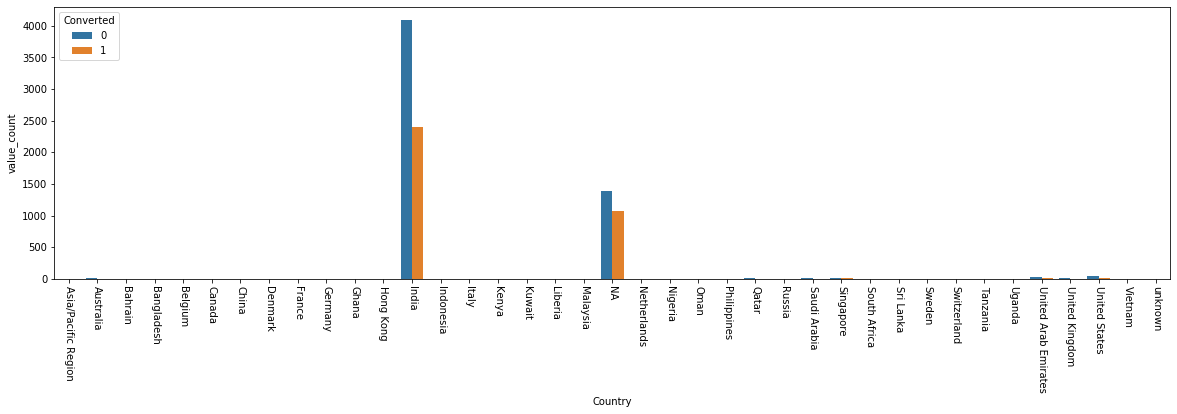

value_count              
Converted                      0       1   All
Country                                       
Asia/Pacific Region          1.0     1.0     2
Australia                   10.0     3.0    13
Bahrain                      3.0     4.0     7
Bangladesh                   1.0     1.0     2
Belgium                      2.0     NaN     2
Canada                       4.0     NaN     4
China                        2.0     NaN     2
Denmark                      NaN     1.0     1
France                       3.0     3.0     6
Germany                      3.0     1.0     4
Ghana                        2.0     NaN     2
Hong Kong                    3.0     4.0     7
India                     4091.0  2401.0  6492
Indonesia                    1.0     NaN     1
Italy                        2.0     NaN     2
Kenya                        1.0     NaN     1
Kuwait                       4.0     NaN     4
Liberia                      1.0     NaN     1
Malaysia                     1.0     NaN     1
NA                        1385.0  1076.0  2461
Netherlands                  1.0     1.0     2
Nigeria                      4.0     NaN     4
Oman                         3.0     3.0     6
Philippines                  2.0     NaN     2
Qatar                        9.0     1.0    10
Russia                       1.0     NaN     1
Saudi Arabia                17.0     4.0    21
Singapore                   13.0    11.0    24
South Africa                 3.0     1.0     4
Sri Lanka                    1.0     NaN     1
Sweden                       2.0     1.0     3
Switzerland                  1.0     NaN     1
Tanzania                     1.0     NaN     1
Uganda                       2.0     NaN     2
United Arab Emirates        33.0    20.0    53
United Kingdom              10.0     5.0    15
United States               51.0    18.0    69
Vietnam                      1.0     NaN     1
unknown                      4.0     1.0     5
All                       5679.0  3561.0  9240

In [126]:


_temp = pd.DataFrame(ds_data[["Country","Converted"]].fillna("NA").groupby(["Country","Converted"])["Converted"].count())

_temp.columns=["value_count"]
_temp.reset_index(inplace = True)

printmd(f"#### Total Missing Values for Country is <font color='red'> {ds_data.Country.isna().sum()} </font>")
printmd(f"Eqlaing to <font color ='red'>{((ds_data.Country.isna().sum() / ds_data.shape[0])*100).round(2)}% </font>")

_temp =_temp.fillna(0)

plt.figure(figsize=(20,5))
ax=sns.barplot(data=_temp,x="Country",y="value_count",hue="Converted")
plt.xticks(rotation=270)
plt.show()


_temp = pd.pivot_table(data=_temp,index=["Country"],values=["value_count"],columns=["Converted"],aggfunc = "sum",margins=True).round()
_temp

# Review Remaks 

70% of profiles are indicating country belongs to india followed by the 21% of data is NA. 
even if we have imputed this with India it will tern to be 91% of students are representing same country. this will not represent any variation hence desided to drop this field


In [127]:
ds_data=ds_data.drop("Country",axis=1)

In [128]:
# Review low missing values 

ds_data.loc[ds_data.TotalVisits.isna()].Lead_Origin.value_counts()

Lead Add Form     110
Lead Import        24
API                 2
Quick Add Form      1
Name: Lead_Origin, dtype: int64

In [129]:
# above indicating that TotalVisits Na that could be related to where the lead is gathered

ds_data.groupby(["Lead_Origin"])["TotalVisits"].median()

Lead_Origin
API                        2.0
Landing Page Submission    4.0
Lead Add Form              0.0
Lead Import                0.0
Quick Add Form             NaN
Name: TotalVisits, dtype: float64

In [130]:
# refering to the above it is indicating that we can fill if Lead Origin amount any of this "Lead Add Form" /  "Lead Import " /"Quick Add Form" we will impute with 0 and API we will impute with 2

ds_data.loc[ ds_data.TotalVisits.isna() & ( ds_data.Lead_Origin == "API" ),"TotalVisits"] = 2 
ds_data.loc[ ds_data.TotalVisits.isna(),"TotalVisits"] = 0

In [131]:
# Review Page_Views_Per_Visit 
ds_data.loc[ds_data.Page_Views_Per_Visit.isna()].Lead_Origin.value_counts()

Lead Add Form     110
Lead Import        24
API                 2
Quick Add Form      1
Name: Lead_Origin, dtype: int64

In [132]:
ds_data.groupby(["Lead_Origin"])["Page_Views_Per_Visit"].median()

Lead_Origin
API                        1.0
Landing Page Submission    3.0
Lead Add Form              0.0
Lead Import                0.0
Quick Add Form             NaN
Name: Page_Views_Per_Visit, dtype: float64

In [133]:
# Review Remaks if Page_Views_Per_Visit is empty and created by API we will impute with 1 else 0 

ds_data.loc[ ds_data.Page_Views_Per_Visit.isna() & ( ds_data.Lead_Origin == "API" ),"Page_Views_Per_Visit"] = 1
ds_data.loc[ ds_data.Page_Views_Per_Visit.isna(),"Page_Views_Per_Visit"] = 0

In [134]:
# study Last_Activity

ds_data.Last_Activity.fillna("NA").value_counts()

Email Opened                    3437
SMS Sent                        2745
Olark Chat Conversation          973
Page Visited on Website          640
Converted to Lead                428
Email Bounced                    326
Email Link Clicked               267
Form Submitted on Website        116
NA                               103
Unreachable                       93
Unsubscribed                      61
Had a Phone Conversation          30
Approached upfront                 9
View in browser link Clicked       6
Email Received                     2
Email Marked Spam                  2
Visited Booth in Tradeshow         1
Resubscribed to emails             1
Name: Last_Activity, dtype: int64

### Review  Remaks 

Based on the above columns maximum occuriences were related to Email Opened. only about 113  are the missing values hence desided to replace with the maximum occurences

In [135]:
# Replaced missing value with the email Opened Status

ds_data.Last_Activity=ds_data.Last_Activity.fillna("Email Opened")

In [136]:
ds_data.Lead_Source.fillna("NA").value_counts()

Google               2868
Direct Traffic       2543
Olark Chat           1755
Organic Search       1154
Reference             534
Welingak Website      142
Referral Sites        125
Facebook               55
NA                     36
bing                    6
google                  5
Click2call              4
Social Media            2
Press_Release           2
Live Chat               2
Pay per Click Ads       1
youtubechannel          1
welearnblog_Home        1
NC_EDM                  1
WeLearn                 1
testone                 1
blog                    1
Name: Lead_Source, dtype: int64

## Review Remaks 

only about 36  variables having null values it is recomended to impute this with the maximum occurences


In [137]:
ds_data.Lead_Source=ds_data.Lead_Source.fillna("Google")

In [138]:
ds_data.isnull().sum(axis=0)

Lead_Origin                                 0
Lead_Source                                 0
Do_Not_Email                                0
Do_Not_Call                                 0
Converted                                   0
TotalVisits                                 0
Total_Time_Spent_on_Website                 0
Page_Views_Per_Visit                        0
Last_Activity                               0
Specialization                              0
Search                                      0
Magazine                                    0
Newspaper_Article                           0
X_Education_Forums                          0
Newspaper                                   0
Digital_Advertisement                       0
Through_Recommendations                     0
Receive_More_Updates_About_Our_Courses      0
Update_me_on_Supply_Chain_Content           0
Get_updates_on_DM_Content                   0
City                                        0
I_agree_to_pay_the_amount_through_

### Summary of Imputation / deletion

- Dropped Prospect ID, Lead Number since these are majorly indicating application sequence numbers’ no 
- Dropped due to not meeting objectives indicating that these fields either created by agents or sales channels considering these fields into the model will not meet our requirements to improve manual work load doing by agents 
Lead Profile & Lead_Quality  , Tags


- Dropped because of  insufficient information or even imputed with the maximum occurrences it may not explain the variance with target variable 
    How_did_you_hear_about_X_Education  
    "Asymmetrique_Profile_Score",
    "Asymmetrique_Activity_Score",
    "Asymmetrique_Profile_Index",
    "Asymmetrique_Activity_Index,
    What_matters_most_to_you_in_choosing_a_course,
    What_is_your_current_occupation
    Country
    
## Perform Univarient Anslysis


#### <font color='green'> Lead_Origin </font> distribution and relationship with Target Variable

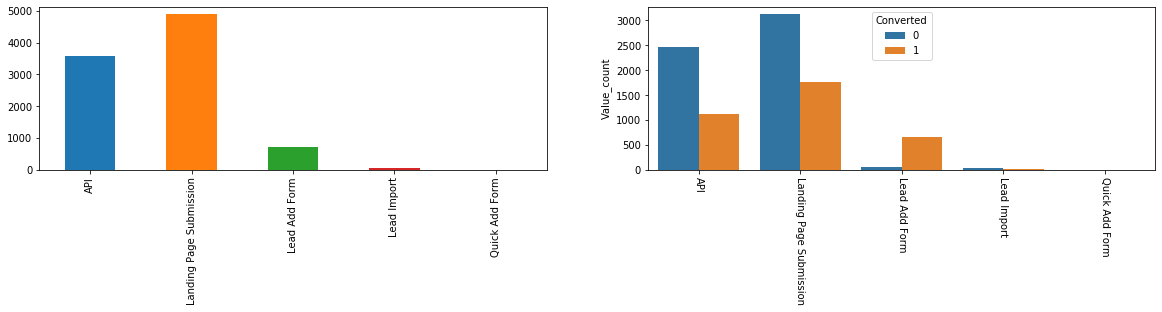

In [139]:
def display_categorical_analysis(colname):
    _temp =pd.DataFrame(ds_data.groupby([colname,"Converted"])["Converted"].count())
    _temp.columns =["Value_count"]
    _temp=_temp.reset_index()
    
    printmd(f"#### <font color='green'> {colname } </font> distribution and relationship with Target Variable")
    
    plt.figure(figsize=(20,3))
    plt.subplot(1,2,1)
    _temp.groupby(colname)["Value_count"].sum().plot(kind="bar")
    plt.xlabel("")

    plt.subplot(1,2,2)
    ax=sns.barplot(data=_temp,x=colname,y="Value_count",hue="Converted")
    plt.xticks(rotation=270)
    plt.xlabel("")
    plt.show()


display_categorical_analysis("Lead_Origin")

###  Review remaks 

- based on the above it is clearly indicating that if lead came from Lead add form indicating high sucess rate remaining all similar ratio.
- it is recomended to perform one hot encodings for this variable

#### <font color='green'> Lead_Source </font> distribution and relationship with Target Variable

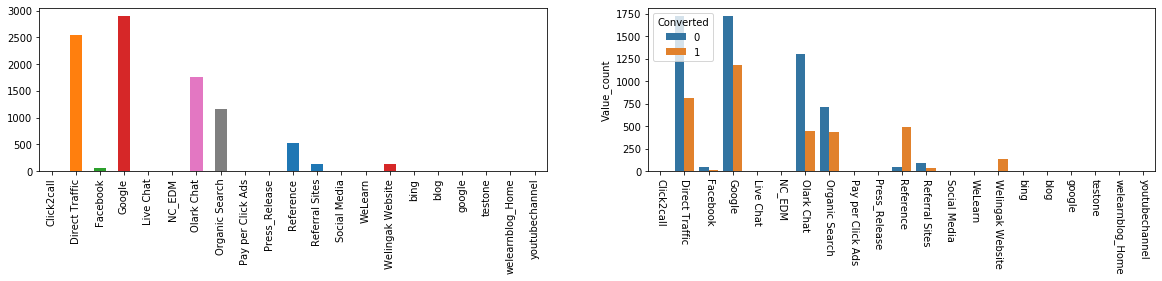

In [140]:
display_categorical_analysis("Lead_Source")

### Review Remaks 

- indicating that major data sources only searches (google /  bing) and direct dite visits  /  chart and referals
- desided to group Google,Organic Search, bing, google  under one group item calls Search
- Direct Traffic, Welingak Website,Referral Sites under the Direct Traffic 
- Olark Chat, Live Chat  as Chat
- Reference = Referral 
- Facebook , Social Media = Social Media 
- and all remaining as Others

In [141]:
ds_data.Lead_Source = ["Serahc_sites" if i in (["Google","Organic Search","google","bing"])  else  i for i in ds_data.Lead_Source]
ds_data.Lead_Source = ["Direct_site" if i in (["Direct Traffic",'Welingak Website'])  else  i for i in ds_data.Lead_Source]
ds_data.Lead_Source = ["Chat_Services" if i in (["Olark Chat",'Live Chat'])  else  i for i in ds_data.Lead_Source]
ds_data.Lead_Source = ["Reference" if i in (["Reference",'Referral Sites'])  else  i for i in ds_data.Lead_Source]
ds_data.Lead_Source = [i if i in (["Serahc_sites",'Direct_site','Chat_Services','Reference'])  else  "Other_Sources" for i in ds_data.Lead_Source]

ds_data.Lead_Source.value_counts()

Serahc_sites     4069
Direct_site      2685
Chat_Services    1757
Reference         659
Other_Sources      70
Name: Lead_Source, dtype: int64

In [142]:
ds_data[ds_data.Lead_Source =="Reference"].groupby("Converted")["Lead_Source"].count()

Converted
0    138
1    521
Name: Lead_Source, dtype: int64

#### <font color='green'> Do_Not_Email </font> distribution and relationship with Target Variable

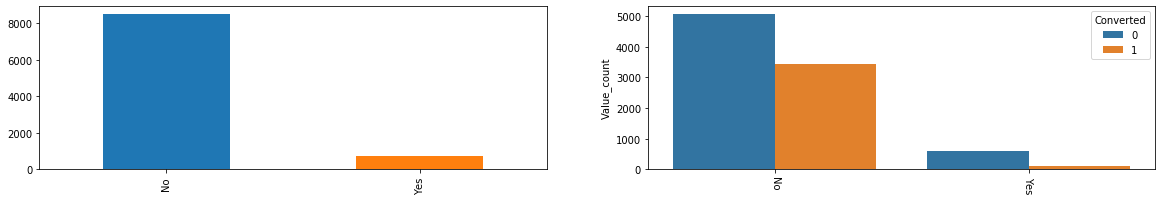

### Distribution of Do_Not_Email

No     8506
Yes     734
Name: Do_Not_Email, dtype: int64


#### <font color='green'> Do_Not_Call </font> distribution and relationship with Target Variable

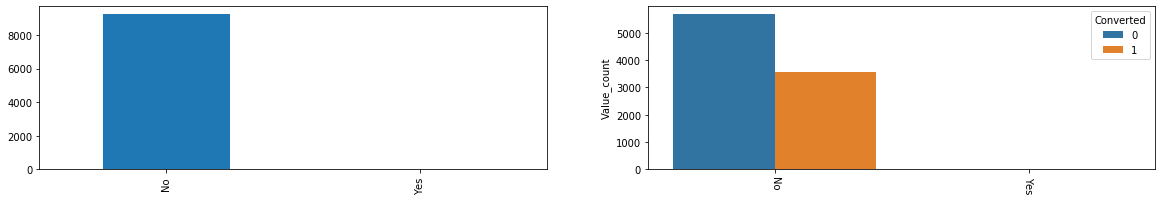

### Distribution of Do_Not_Call

No     9238
Yes       2
Name: Do_Not_Call, dtype: int64


In [143]:
# analyse Do_Not_Email & call categorical variable
display_categorical_analysis("Do_Not_Email")
printmd("### Distribution of Do_Not_Email")
print(ds_data.Do_Not_Email.value_counts())


display_categorical_analysis("Do_Not_Call")
printmd("### Distribution of Do_Not_Call")
print(ds_data.Do_Not_Call.value_counts())


# Review Remaks

- with regards to Do_not Email around only 8% of leads are selected do not email. even though data is not explaining major variations we will keep until  the model desided
- with regards to the do not call. even it is importent indicator only 2 leads were selected Yes remaining all selected No. in that case it will not add any value to us so we will remove this column

In [144]:
# Droping  Do_Not_Call ineffective field 

ds_data=ds_data.drop("Do_Not_Call",axis=1)

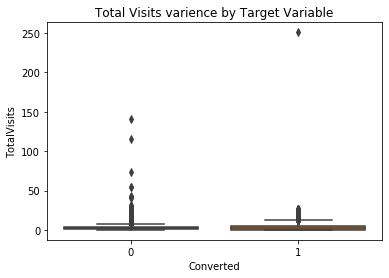

In [145]:
# Review Total Visits
sns.boxplot(data=ds_data,y="TotalVisits",x="Converted")
plt.title("Total Visits varience by Target Variable")
plt.show()

## Review Remaks 

- Above Total Visits clearly indicating some outliers. we will treated these ouliers in away if any numbers appeared to be more than quantile ranges of 95% will replace with the 95% border

In [146]:

# Identify the boundery for TotalVisits for 95% quantile
end_bound=ds_data.TotalVisits.quantile(0.95)

ds_data.TotalVisits= [i if i <=end_bound else end_bound for i in  ds_data.TotalVisits]

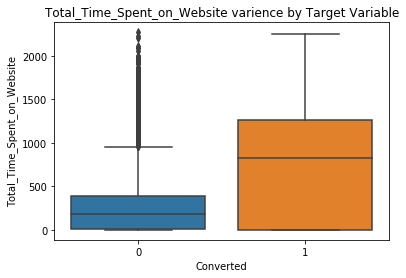

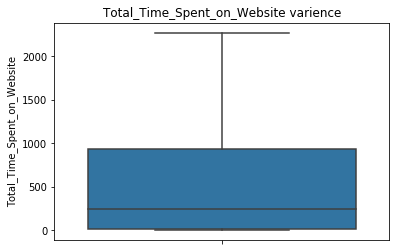

In [147]:
# Review  of Total_Time_Spent_on_Website

sns.boxplot(data=ds_data,y="Total_Time_Spent_on_Website",x="Converted")
plt.title("Total_Time_Spent_on_Website varience by Target Variable")
plt.show()

sns.boxplot(data=ds_data,y="Total_Time_Spent_on_Website")
plt.title("Total_Time_Spent_on_Website varience")
plt.show()

# Review Summary

- Even it indicating some extream values for Target Zero. but these values are indicated normal if we consider entrire set.
- Not required to impute 


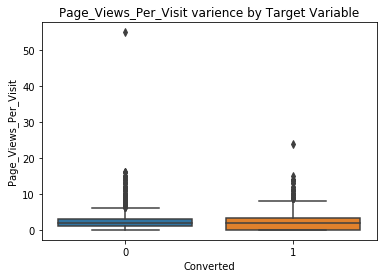

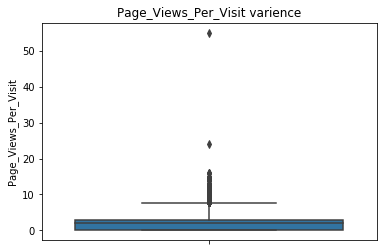

In [148]:
# Review Page_Views_Per_Visit                        

sns.boxplot(data=ds_data,y="Page_Views_Per_Visit",x="Converted")
plt.title("Page_Views_Per_Visit varience by Target Variable")
plt.show()

sns.boxplot(data=ds_data,y="Page_Views_Per_Visit")
plt.title("Page_Views_Per_Visit varience")
plt.show()

# Review Remaks 

- Overall indicating outliers irrespective of with target variabl
- we will reset bounderies by replacing with 95% quantile for extream values

In [149]:
# Outlier treatment for  Page_Views_Per_Visit 

end_bound=ds_data.Page_Views_Per_Visit.quantile(0.95)

ds_data.Page_Views_Per_Visit= [i if i <=end_bound else end_bound for i in  ds_data.Page_Views_Per_Visit]

#### <font color='green'> Last_Activity </font> distribution and relationship with Target Variable

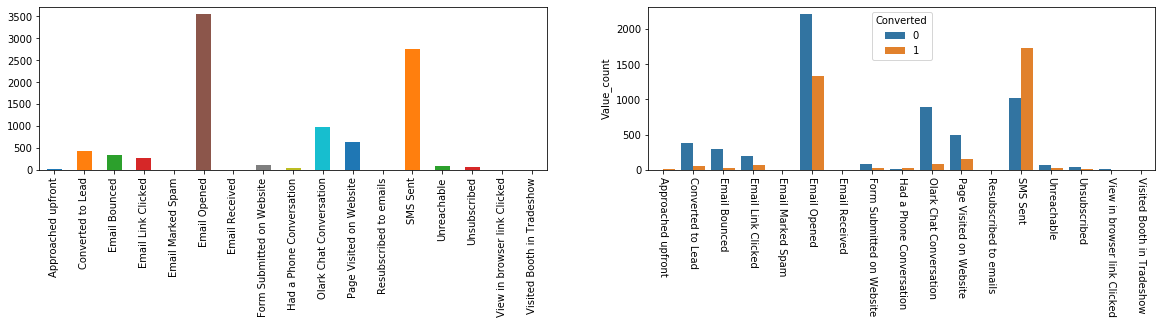

### Distribution of Last_Activity

Email Opened                    3540
SMS Sent                        2745
Olark Chat Conversation          973
Page Visited on Website          640
Converted to Lead                428
Email Bounced                    326
Email Link Clicked               267
Form Submitted on Website        116
Unreachable                       93
Unsubscribed                      61
Had a Phone Conversation          30
Approached upfront                 9
View in browser link Clicked       6
Email Received                     2
Email Marked Spam                  2
Visited Booth in Tradeshow         1
Resubscribed to emails             1
Name: Last_Activity, dtype: int64


In [150]:
# Review Last_Activity                               
display_categorical_analysis("Last_Activity")
printmd("### Distribution of Last_Activity")
print(ds_data.Last_Activity.value_counts())

### Review Comments 

levels lesser than 30 will not help us to judge it is better to replace with the other type of activities

In [151]:
_temp =ds_data.Last_Activity.value_counts()
ds_data.Last_Activity=ds_data.Last_Activity.replace(_temp[_temp<=30].index,"Other_Activities")

#### <font color='green'> Specialization </font> distribution and relationship with Target Variable

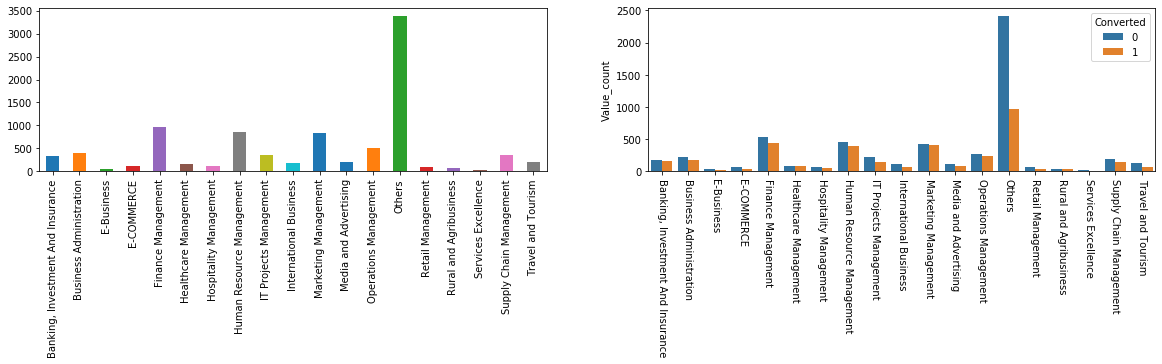

### Distribution of Specialization

Others                               3380
Finance Management                    976
Human Resource Management             848
Marketing Management                  838
Operations Management                 503
Business Administration               403
IT Projects Management                366
Supply Chain Management               349
Banking, Investment And Insurance     338
Travel and Tourism                    203
Media and Advertising                 203
International Business                178
Healthcare Management                 159
Hospitality Management                114
E-COMMERCE                            112
Retail Management                     100
Rural and Agribusiness                 73
E-Business                             57
Services Excellence                    40
Name: Specialization, dtype: int64


In [152]:
# Review Specialization                               
display_categorical_analysis("Specialization")
printmd("### Distribution of Specialization")
print(ds_data.Specialization.value_counts())

## Review Comments

- Major values are imputed "Others" we will review during model development 

#### <font color='green'> Search </font> distribution and relationship with Target Variable

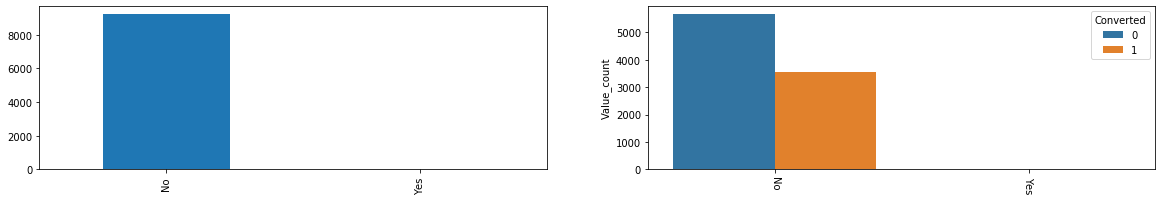

### Distribution of Search

No     9226
Yes      14
Name: Search, dtype: int64


In [153]:
#Review Search

display_categorical_analysis("Search")
printmd("### Distribution of Search")
print(ds_data.Search.value_counts())
                              

# Review Comments 

Seems Search field has all defualt values. we are going to drop this columns

In [154]:
ds_data = ds_data.drop("Search",axis=1)

#### <font color='green'> Magazine </font> distribution and relationship with Target Variable

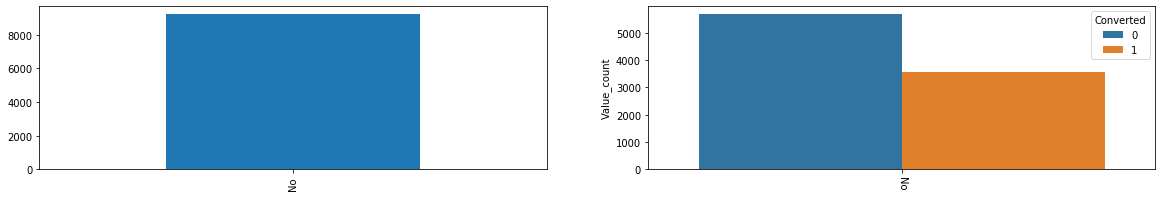

### Distribution of Magazine

No    9240
Name: Magazine, dtype: int64


In [155]:
#ds_data.Magazine                                

display_categorical_analysis("Magazine")
printmd("### Distribution of Magazine")
print(ds_data.Magazine.value_counts())

# Review comments

Magazine has only one variable hence this will not be usefull categorical field

In [156]:
# droping Magazine field 
ds_data = ds_data.drop("Magazine",axis=1)

#### <font color='green'> Newspaper_Article </font> distribution and relationship with Target Variable

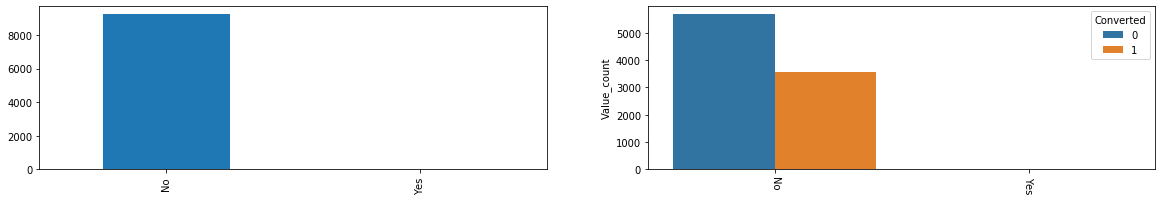

### Distribution of Newspaper_Article

No     9238
Yes       2
Name: Newspaper_Article, dtype: int64


In [157]:
# Newspaper_Article                           

display_categorical_analysis("Newspaper_Article")
printmd("### Distribution of Newspaper_Article")
print(ds_data.Newspaper_Article.value_counts())

In [158]:
# since Newspaper_Article not adding any value we are going to remove this field 

ds_data = ds_data.drop("Newspaper_Article",axis=1)

#### <font color='green'> X_Education_Forums </font> distribution and relationship with Target Variable

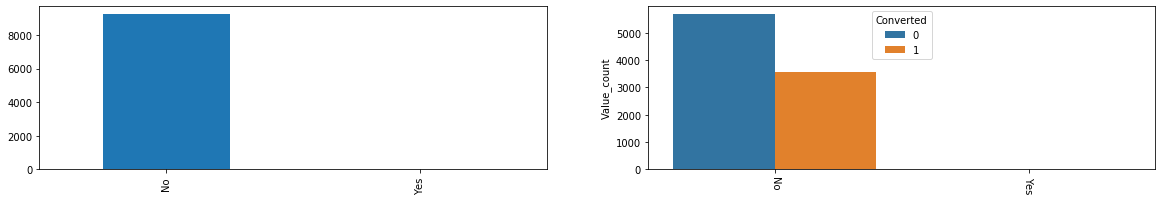

### Distribution of X_Education_Forums

No     9239
Yes       1
Name: X_Education_Forums, dtype: int64


In [159]:
# X_Education_Forums                          


display_categorical_analysis("X_Education_Forums")
printmd("### Distribution of X_Education_Forums")
print(ds_data.X_Education_Forums.value_counts())

In [160]:
# since X_Education_Forums not adding any value we are going to remove this field 

ds_data = ds_data.drop("X_Education_Forums",axis=1)

#### <font color='green'> Newspaper </font> distribution and relationship with Target Variable

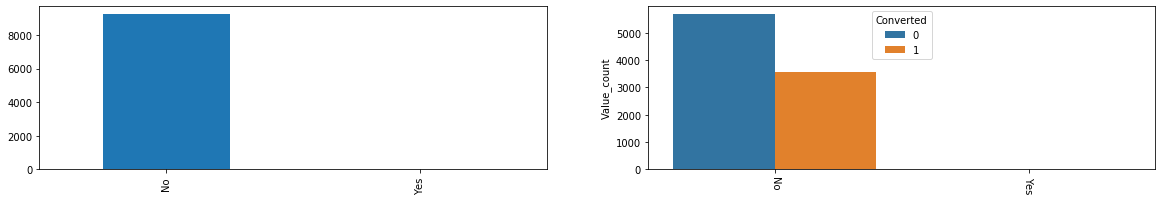

### Distribution of Newspaper

No     9239
Yes       1
Name: Newspaper, dtype: int64


In [161]:
# Newspaper                                   


display_categorical_analysis("Newspaper")
printmd("### Distribution of Newspaper")
print(ds_data.Newspaper.value_counts())

In [162]:
# since Newspaper not adding any value we are going to remove this field 

ds_data = ds_data.drop("Newspaper",axis=1)

#### <font color='green'> Digital_Advertisement </font> distribution and relationship with Target Variable

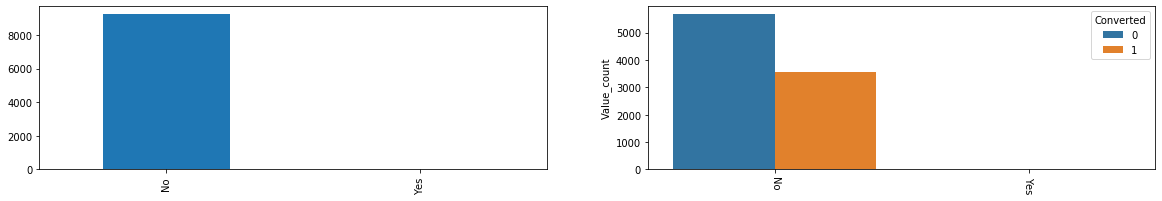

### Distribution of Digital_Advertisement

No     9236
Yes       4
Name: Digital_Advertisement, dtype: int64


In [163]:
# Digital_Advertisement                       


display_categorical_analysis("Digital_Advertisement")
printmd("### Distribution of Digital_Advertisement")
print(ds_data.Digital_Advertisement.value_counts())

In [164]:
# since Digital_Advertisement not adding any value we are going to remove this field 

ds_data = ds_data.drop("Digital_Advertisement",axis=1)

#### <font color='green'> Through_Recommendations </font> distribution and relationship with Target Variable

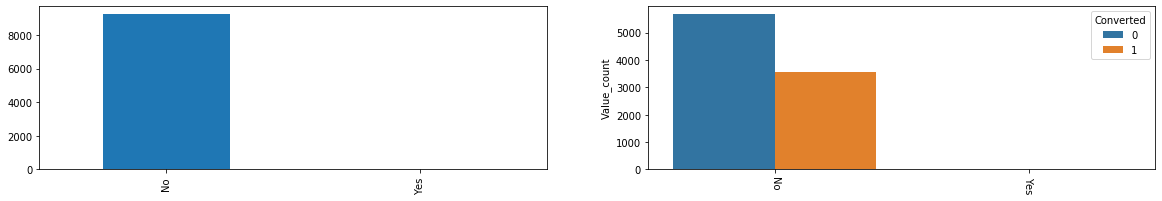

### Distribution of Through_Recommendations

No     9233
Yes       7
Name: Through_Recommendations, dtype: int64


In [165]:
# Through_Recommendations  

display_categorical_analysis("Through_Recommendations")
printmd("### Distribution of Through_Recommendations")
print(ds_data.Through_Recommendations.value_counts())

In [166]:
# since Through_Recommendations not adding any value we are going to remove this field 

ds_data = ds_data.drop("Through_Recommendations",axis=1)

#### <font color='green'> Receive_More_Updates_About_Our_Courses </font> distribution and relationship with Target Variable

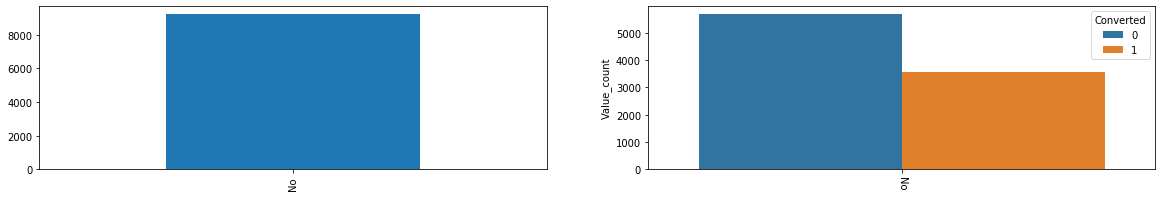

### Distribution of Receive_More_Updates_About_Our_Courses

No    9240
Name: Receive_More_Updates_About_Our_Courses, dtype: int64


In [167]:
# Receive_More_Updates_About_Our_Courses

display_categorical_analysis("Receive_More_Updates_About_Our_Courses")
printmd("### Distribution of Receive_More_Updates_About_Our_Courses")
print(ds_data.Receive_More_Updates_About_Our_Courses.value_counts())


In [168]:
# since Receive_More_Updates_About_Our_Courses not adding any value we are going to remove this field 

ds_data = ds_data.drop("Receive_More_Updates_About_Our_Courses",axis=1)

#### <font color='green'> Update_me_on_Supply_Chain_Content </font> distribution and relationship with Target Variable

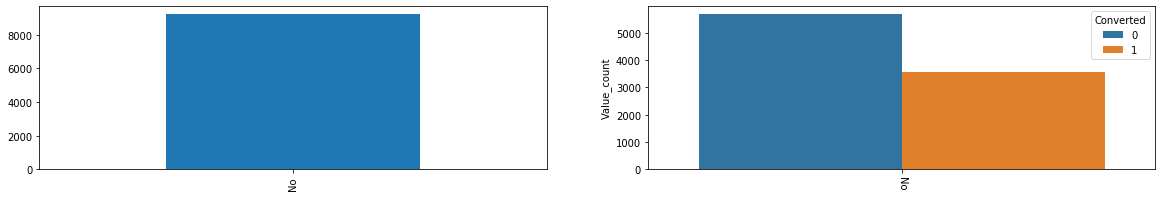

### Distribution of Update_me_on_Supply_Chain_Content

No    9240
Name: Update_me_on_Supply_Chain_Content, dtype: int64


In [169]:
# Update_me_on_Supply_Chain_Content


display_categorical_analysis("Update_me_on_Supply_Chain_Content")
printmd("### Distribution of Update_me_on_Supply_Chain_Content")
print(ds_data.Update_me_on_Supply_Chain_Content.value_counts())

In [170]:
# since Update_me_on_Supply_Chain_Content not adding any value we are going to remove this field 

ds_data = ds_data.drop("Update_me_on_Supply_Chain_Content",axis=1)

#### <font color='green'> Get_updates_on_DM_Content </font> distribution and relationship with Target Variable

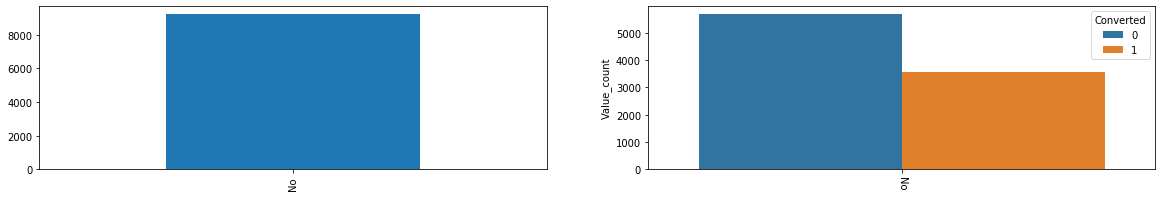

### Distribution of Get_updates_on_DM_Content

No    9240
Name: Get_updates_on_DM_Content, dtype: int64


In [171]:
# Get_updates_on_DM_Content                   

display_categorical_analysis("Get_updates_on_DM_Content")
printmd("### Distribution of Get_updates_on_DM_Content")
print(ds_data.Get_updates_on_DM_Content.value_counts())

In [172]:
# since Get_updates_on_DM_Content not adding any value we are going to remove this field 

ds_data = ds_data.drop("Get_updates_on_DM_Content",axis=1)

#### <font color='green'> City </font> distribution and relationship with Target Variable

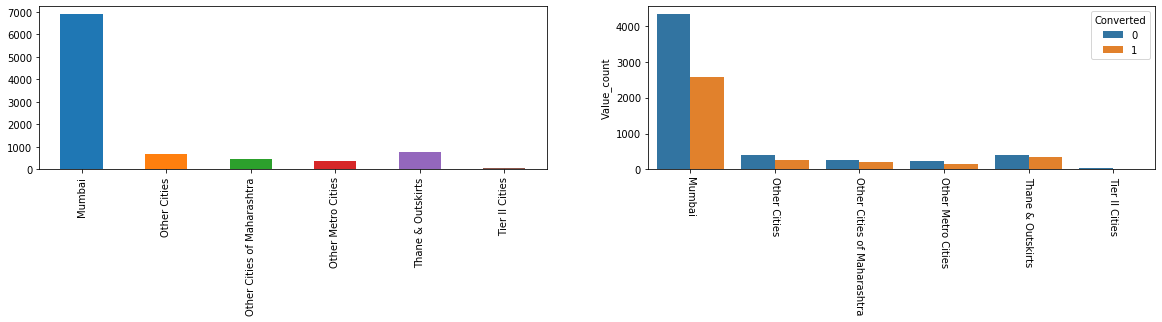

### Distribution of City

Mumbai                         6891
Thane & Outskirts               752
Other Cities                    686
Other Cities of Maharashtra     457
Other Metro Cities              380
Tier II Cities                   74
Name: City, dtype: int64


In [173]:
# City                   

display_categorical_analysis("City")
printmd("### Distribution of City")
print(ds_data.City.value_counts())

### Review  Comments

Even we have imputed NA with the maximum occurences we will see how this field will be usefull for prediction in the model 
not doing any trsnformation on this field

#### <font color='green'> I_agree_to_pay_the_amount_through_cheque </font> distribution and relationship with Target Variable

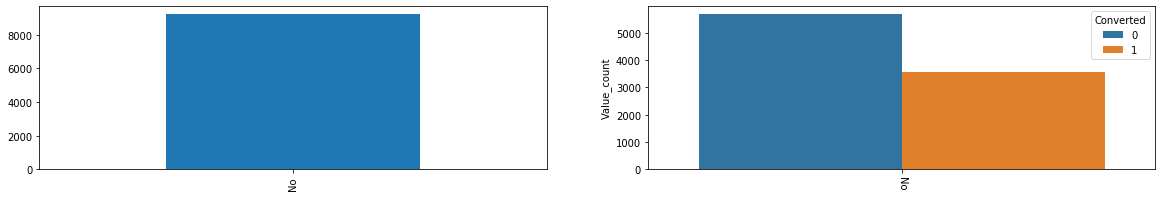

### Distribution of I_agree_to_pay_the_amount_through_cheque

No    9240
Name: I_agree_to_pay_the_amount_through_cheque, dtype: int64


In [174]:
#I_agree_to_pay_the_amount_through_cheque    

display_categorical_analysis("I_agree_to_pay_the_amount_through_cheque")
printmd("### Distribution of I_agree_to_pay_the_amount_through_cheque")
print(ds_data.I_agree_to_pay_the_amount_through_cheque.value_counts())

In [175]:
# since I_agree_to_pay_the_amount_through_cheque not adding any value we are going to remove this field 

ds_data = ds_data.drop("I_agree_to_pay_the_amount_through_cheque",axis=1)

#### <font color='green'> A_free_copy_of_Mastering_The_Interview </font> distribution and relationship with Target Variable

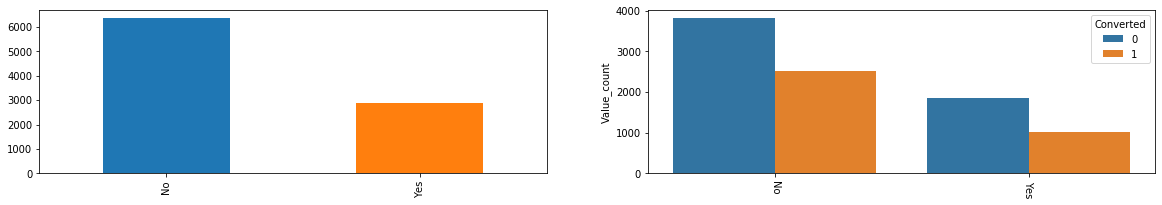

### Distribution of A_free_copy_of_Mastering_The_Interview

No     6352
Yes    2888
Name: A_free_copy_of_Mastering_The_Interview, dtype: int64


In [176]:
# A_free_copy_of_Mastering_The_Interview      

display_categorical_analysis("A_free_copy_of_Mastering_The_Interview")
printmd("### Distribution of A_free_copy_of_Mastering_The_Interview")
print(ds_data.A_free_copy_of_Mastering_The_Interview.value_counts())

### Review comments 

We will review how this field will be usefull in predictions in the model building. 

#### <font color='green'> Last_Notable_Activity </font> distribution and relationship with Target Variable

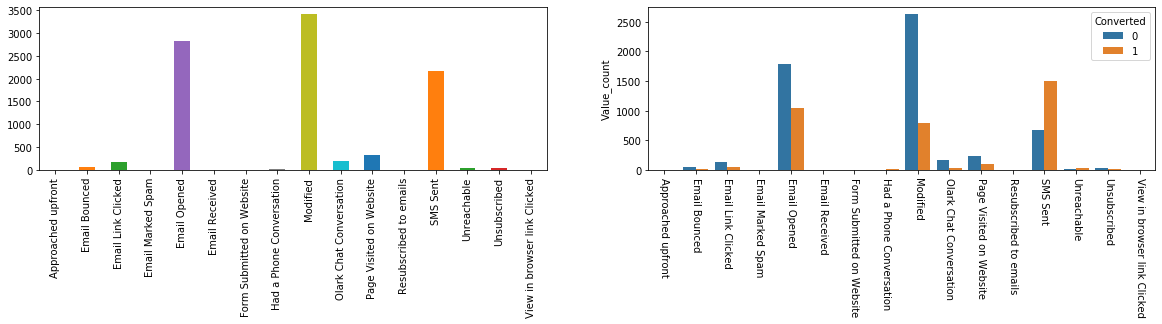

### Distribution of Last_Notable_Activity

Modified                        3407
Email Opened                    2827
SMS Sent                        2172
Page Visited on Website          318
Olark Chat Conversation          183
Email Link Clicked               173
Email Bounced                     60
Unsubscribed                      47
Unreachable                       32
Had a Phone Conversation          14
Email Marked Spam                  2
Email Received                     1
Resubscribed to emails             1
Approached upfront                 1
Form Submitted on Website          1
View in browser link Clicked       1
Name: Last_Notable_Activity, dtype: int64


In [177]:
# Last_Notable_Activity                       

display_categorical_analysis("Last_Notable_Activity")
printmd("### Distribution of Last_Notable_Activity")
print(ds_data.Last_Notable_Activity.value_counts())

In [178]:
# BY seeing the data both Last Notable activity and Last Aactivity is in similar in nature we will review how it is different comparing with the last activity

pd.DataFrame(ds_data.groupby(["Last_Notable_Activity","Last_Activity"])["Converted"].count())

,,Converted
Last_Notable_Activity,Last_Activity,
Approached upfront,Other_Activities,1
Email Bounced,Email Bounced,60
Email Link Clicked,Email Link Clicked,173
Email Marked Spam,Other_Activities,2
Email Opened,Email Opened,2827
Email Received,Other_Activities,1
Form Submitted on Website,Form Submitted on Website,1
Had a Phone Conversation,Other_Activities,14
Modified,Converted to Lead,428


### Review comments 

- Based on the above it is indicates the lead activity and Last_Notable_Activity indicating similar levels and lead activity expalaining more detailed than Last_Notable_Activity
- in that case we don;t need to have same fields so desided to removed this column

In [179]:
ds_data = ds_data.drop("Last_Notable_Activity",axis=1)

In [180]:
printmd(f"### Shape of Final Data Set is <font color='red' > {ds_data.shape} </font>")

ds_data.head()

### Shape of Final Data Set is <font color='red' > (9240, 11) </font>

,Lead_Origin,Lead_Source,Do_Not_Email,Converted,TotalVisits,Total_Time_Spent_on_Website,Page_Views_Per_Visit,Last_Activity,Specialization,City,A_free_copy_of_Mastering_The_Interview
0,API,Chat_Services,No,0,0.0,0,0.0,Page Visited on Website,Others,Mumbai,No
1,API,Serahc_sites,No,0,5.0,674,2.5,Email Opened,Others,Mumbai,No
2,Landing Page Submission,Direct_site,No,1,2.0,1532,2.0,Email Opened,Business Administration,Mumbai,Yes
3,Landing Page Submission,Direct_site,No,0,1.0,305,1.0,Unreachable,Media and Advertising,Mumbai,No
4,Landing Page Submission,Serahc_sites,No,1,2.0,1428,1.0,Converted to Lead,Others,Mumbai,No


### Review Summary After data Cleaning 

- Major number of categorical fields removed since most of the data elements contain only either 1 level or very low magnitude of send level
- Few columns removed because of Lot of Missing values 
- Few columns encodeded with the better meaningful convertion and addressing low magnitude columns 
- treated outliers in the data set 

### Data Trsnformation 
- encoding binary field encoding 
- dummy variable encoding for multi level categorical variables 
- Divide data set to test and training
- scalling for numarical fields 

In [181]:
ds_stage_1= ds_data.copy()


single_level_columns =["Do_Not_Email","A_free_copy_of_Mastering_The_Interview"]
multi_level_columns =["Lead_Origin","Lead_Source","Last_Activity","Specialization","City"]
Continuous_values =["TotalVisits","Total_Time_Spent_on_Website","Page_Views_Per_Visit"]


# Binary values Treatment 

for col in single_level_columns:
    ds_stage_1[col]  = [1 if i =="Yes" else 0 for i in ds_stage_1[col]]
    
dummies= pd.get_dummies(ds_stage_1[multi_level_columns],prefix=multi_level_columns,drop_first =True)

#Merge dummies to the stage 1 data set
ds_stage_1=pd.concat([ds_stage_1,dummies],axis=1)

# drop the original columns
ds_stage_1=ds_stage_1.drop(multi_level_columns,axis=1)

printmd(f"### Shape of a data set after creating dummy variables <font color ='red' > {ds_stage_1.shape} </font>")

ds_stage_1.head()

### Shape of a data set after creating dummy variables <font color ='red' > (9240, 47) </font>

,Do_Not_Email,Converted,TotalVisits,Total_Time_Spent_on_Website,Page_Views_Per_Visit,A_free_copy_of_Mastering_The_Interview,Lead_Origin_Landing Page Submission,Lead_Origin_Lead Add Form,Lead_Origin_Lead Import,Lead_Origin_Quick Add Form,Lead_Source_Direct_site,Lead_Source_Other_Sources,Lead_Source_Reference,Lead_Source_Serahc_sites,Last_Activity_Email Bounced,Last_Activity_Email Link Clicked,Last_Activity_Email Opened,Last_Activity_Form Submitted on Website,Last_Activity_Olark Chat Conversation,Last_Activity_Other_Activities,Last_Activity_Page Visited on Website,Last_Activity_SMS Sent,Last_Activity_Unreachable,Last_Activity_Unsubscribed,Specialization_Business Administration,Specialization_E-Business,Specialization_E-COMMERCE,Specialization_Finance Management,Specialization_Healthcare Management,Specialization_Hospitality Management,Specialization_Human Resource Management,Specialization_IT Projects Management,Specialization_International Business,Specialization_Marketing Management,Specialization_Media and Advertising,Specialization_Operations Management,Specialization_Others,Specialization_Retail Management,Specialization_Rural and Agribusiness,Specialization_Services Excellence,Specialization_Supply Chain Management,Specialization_Travel and Tourism,City_Other Cities,City_Other Cities of Maharashtra,City_Other Metro Cities,City_Thane & Outskirts,City_Tier II Cities
0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,0,5.0,674,2.5,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,1,2.0,1532,2.0,1,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,1.0,305,1.0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,0,1,2.0,1428,1.0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [182]:
# Split the data into train and test data set 

train_ds,test_ds =train_test_split(ds_stage_1,train_size =0.77,random_state =100)

printmd(f"### Shape of a training data set <font color ='red' > {train_ds.shape} </font>, Number of True Values {train_ds[train_ds.Converted ==1].shape[0]}")
printmd(f"### Shape of a test_ds data set <font color ='red' > {test_ds.shape} </font> , Number of True Values {test_ds[test_ds.Converted ==1].shape[0]}")

X_train = train_ds.copy()
y_train = X_train.pop("Converted")

X_test = test_ds.copy()
y_test = X_test.pop("Converted")

printmd(f"### Final X Train shape  {X_train.shape}")

### Shape of a training data set <font color ='red' > (7114, 47) </font>, Number of True Values 2729

### Shape of a test_ds data set <font color ='red' > (2126, 47) </font> , Number of True Values 832

### Final X Train shape  (7114, 46)

In [183]:
# Scaling Numarical Data on x variable 

scaler = StandardScaler()

X_train[Continuous_values]=scaler.fit_transform(X_train[Continuous_values])

X_train.describe().round(2)

,Do_Not_Email,TotalVisits,Total_Time_Spent_on_Website,Page_Views_Per_Visit,A_free_copy_of_Mastering_The_Interview,Lead_Origin_Landing Page Submission,Lead_Origin_Lead Add Form,Lead_Origin_Lead Import,Lead_Origin_Quick Add Form,Lead_Source_Direct_site,Lead_Source_Other_Sources,Lead_Source_Reference,Lead_Source_Serahc_sites,Last_Activity_Email Bounced,Last_Activity_Email Link Clicked,Last_Activity_Email Opened,Last_Activity_Form Submitted on Website,Last_Activity_Olark Chat Conversation,Last_Activity_Other_Activities,Last_Activity_Page Visited on Website,Last_Activity_SMS Sent,Last_Activity_Unreachable,Last_Activity_Unsubscribed,Specialization_Business Administration,Specialization_E-Business,Specialization_E-COMMERCE,Specialization_Finance Management,Specialization_Healthcare Management,Specialization_Hospitality Management,Specialization_Human Resource Management,Specialization_IT Projects Management,Specialization_International Business,Specialization_Marketing Management,Specialization_Media and Advertising,Specialization_Operations Management,Specialization_Others,Specialization_Retail Management,Specialization_Rural and Agribusiness,Specialization_Services Excellence,Specialization_Supply Chain Management,Specialization_Travel and Tourism,City_Other Cities,City_Other Cities of Maharashtra,City_Other Metro Cities,City_Thane & Outskirts,City_Tier II Cities
count,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.0,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00,7114.00
mean,0.08,0.00,-0.00,0.00,0.31,0.53,0.08,0.01,0.00,0.29,0.01,0.07,0.44,0.04,0.03,0.38,0.01,0.1,0.01,0.07,0.30,0.01,0.01,0.04,0.01,0.01,0.11,0.02,0.01,0.09,0.04,0.02,0.09,0.02,0.06,0.37,0.01,0.01,0.00,0.04,0.02,0.08,0.05,0.04,0.08,0.01
std,0.27,1.00,1.00,1.00,0.46,0.50,0.27,0.07,0.01,0.45,0.08,0.26,0.50,0.19,0.16,0.49,0.11,0.3,0.08,0.26,0.46,0.09,0.08,0.20,0.07,0.11,0.31,0.13,0.11,0.29,0.19,0.14,0.29,0.14,0.23,0.48,0.10,0.09,0.07,0.19,0.15,0.26,0.22,0.20,0.27,0.09
min,0.00,-1.12,-0.88,-1.23,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,-1.12,-0.86,-1.23,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,-0.05,-0.43,-0.12,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,0.00,0.67,0.81,0.44,1.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.0,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,1.00,2.47,3.27,2.11,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


### Review Comments 

- Completed data cleanup excerise
- Prepared data by means of creating dummy variables 
- split the data for modeling 
- scaled all numarical properties 
- xtrain is having 46 variables with 7114 observations
- Spliting training and test preserve the true values at the original rate

### Model Preparation

- verify if data set has any multicollinearity 
- perform RFE for selecting top 15 variables to start with and delete unwanted variables based on P Value and VIF
- calculate model validation parameters like model accuracy, Sensitivity, Precision and Specificity 

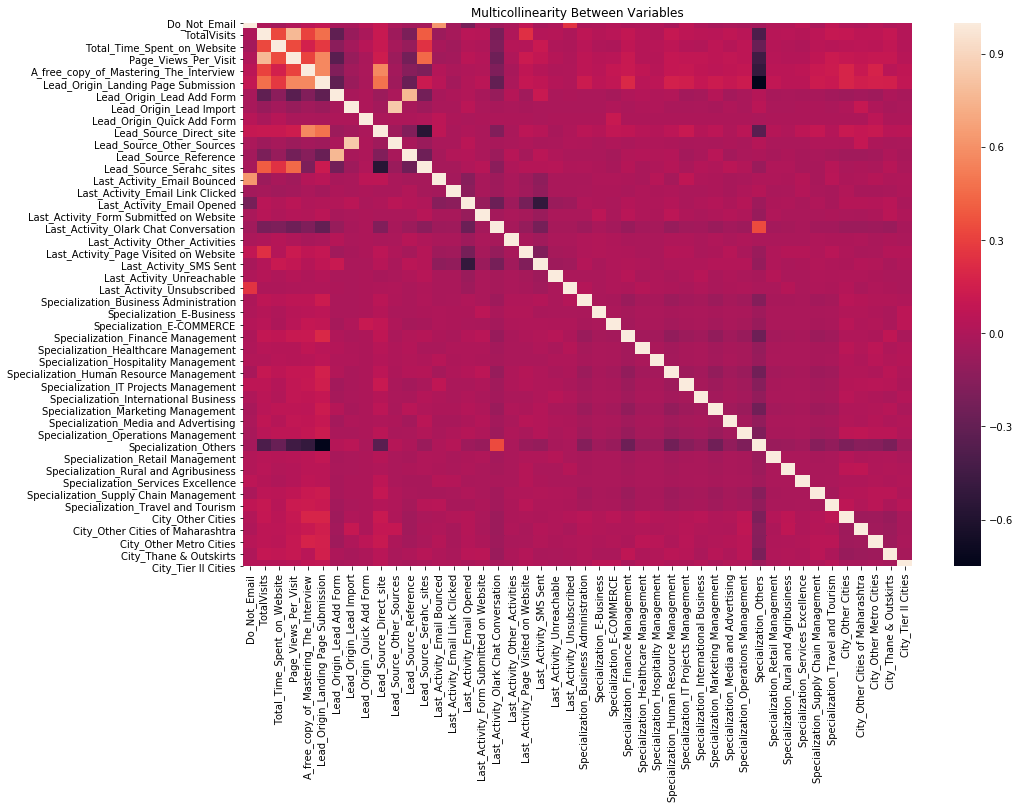

In [184]:
plt.figure(figsize=(15,10))
sns.heatmap(X_train.corr())
plt.title("Multicollinearity Between Variables")
plt.show()


## Review Remaks

- By seeing the data we can visualize top right cornor is having high +ve correlation
- will see first these columns having any influence on target variable 

In [185]:
# Perform RFE for top 15 variables if we can minimize number of variables

model = LogisticRegression()
model.fit(X_train,y_train)

rfe= RFE(model,20)

rfe.fit(X_train,y_train)

final_columns = list(X_train.columns[rfe.support_])

In [186]:
def Calculate_VIF(X_train,columns):
    vif = pd.DataFrame()
    vif["Variable"] = columns
    _temp = X_train[columns].copy()
    vif["score"] = [variance_inflation_factor(_temp.values,i) for i in range(len(columns))]
    vif = vif.sort_values(by="score",ascending =False)
    return vif

# Modeling with the Statsmodel 

model = sm.GLM(y_train,(sm.add_constant(X_train[final_columns])), family = sm.families.Binomial())
fit = model.fit()
print(fit.summary())


# print VIF
Calculate_VIF(X_train,final_columns)       

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Converted   No. Observations:                 7114
Model:                            GLM   Df Residuals:                     7093
Model Family:                Binomial   Df Model:                           20
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3102.0
Date:                Sun, 25 Aug 2019   Deviance:                       6204.0
Time:                        21:06:53   Pearson chi2:                 7.57e+03
No. Iterations:                     6   Covariance Type:             nonrobust
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                     0.4723      0.158      2.992      0

,Variable,score
3,Lead_Origin_Landing Page Submission,6.782035
9,Lead_Source_Serahc_sites,4.788162
6,Lead_Source_Direct_site,4.512546
7,Lead_Source_Other_Sources,3.423791
5,Lead_Origin_Lead Import,3.401543
4,Lead_Origin_Lead Add Form,3.281016
19,Specialization_Others,3.103345
8,Lead_Source_Reference,3.092903
11,Last_Activity_Email Opened,2.684523
14,Last_Activity_SMS Sent,2.347422


### Review comments 

- Initial model indicates that Lead_Origin_Lead Import indicating high P Value will remove this field and try modeling 

In [187]:
final_columns.remove("Lead_Origin_Lead Import")

model = sm.GLM(y_train,(sm.add_constant(X_train[final_columns])), family = sm.families.Binomial())
fit = model.fit()
print(fit.summary())


# print VIF
Calculate_VIF(X_train,final_columns)    


                 Generalized Linear Model Regression Results                  
Dep. Variable:              Converted   No. Observations:                 7114
Model:                            GLM   Df Residuals:                     7094
Model Family:                Binomial   Df Model:                           19
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3102.0
Date:                Sun, 25 Aug 2019   Deviance:                       6204.0
Time:                        21:06:53   Pearson chi2:                 7.57e+03
No. Iterations:                     6   Covariance Type:             nonrobust
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                     0.4724      0.158      2.993      0

,Variable,score
3,Lead_Origin_Landing Page Submission,6.737114
8,Lead_Source_Serahc_sites,4.766388
5,Lead_Source_Direct_site,4.487972
4,Lead_Origin_Lead Add Form,3.254730
18,Specialization_Others,3.102257
7,Lead_Source_Reference,3.081363
10,Last_Activity_Email Opened,2.683768
13,Last_Activity_SMS Sent,2.346379
1,TotalVisits,1.680498
11,Last_Activity_Olark Chat Conversation,1.554520


# Review Comments 

- Last_Activity_Email Link Clicked indicating high P Value of 0.150 will remove and develop the model

In [188]:
final_columns.remove("Last_Activity_Email Link Clicked")

model = sm.GLM(y_train,(sm.add_constant(X_train[final_columns])), family = sm.families.Binomial())
fit = model.fit()
print(fit.summary())


# print VIF
Calculate_VIF(X_train,final_columns) 

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Converted   No. Observations:                 7114
Model:                            GLM   Df Residuals:                     7095
Model Family:                Binomial   Df Model:                           18
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3103.0
Date:                Sun, 25 Aug 2019   Deviance:                       6206.0
Time:                        21:06:53   Pearson chi2:                 7.57e+03
No. Iterations:                     6   Covariance Type:             nonrobust
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                     0.5386      0.151      3.572      0

,Variable,score
3,Lead_Origin_Landing Page Submission,6.622134
8,Lead_Source_Serahc_sites,4.733231
5,Lead_Source_Direct_site,4.471931
4,Lead_Origin_Lead Add Form,3.254720
7,Lead_Source_Reference,3.059412
17,Specialization_Others,2.981095
9,Last_Activity_Email Opened,2.509809
12,Last_Activity_SMS Sent,2.216079
1,TotalVisits,1.675527
10,Last_Activity_Olark Chat Conversation,1.508234


### Review comments 

- Specialization_International Business indicating higher marginally higher P Value 
- Lead_Origin_Landing Page Submission indicates higher correlation 
- first we will remove Lead_Origin_Landing Page Submission and see the model improves are not

In [189]:
final_columns.remove("Lead_Origin_Landing Page Submission")

model = sm.GLM(y_train,(sm.add_constant(X_train[final_columns])), family = sm.families.Binomial())
fit = model.fit()
print(fit.summary())


# print VIF
Calculate_VIF(X_train,final_columns) 

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Converted   No. Observations:                 7114
Model:                            GLM   Df Residuals:                     7096
Model Family:                Binomial   Df Model:                           17
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3152.7
Date:                Sun, 25 Aug 2019   Deviance:                       6305.4
Time:                        21:06:54   Pearson chi2:                 7.49e+03
No. Iterations:                     6   Covariance Type:             nonrobust
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -0.0573      0.135     -0.424      0

,Variable,score
3,Lead_Origin_Lead Add Form,2.944031
6,Lead_Source_Reference,2.866927
7,Lead_Source_Serahc_sites,2.762694
8,Last_Activity_Email Opened,2.337024
11,Last_Activity_SMS Sent,2.066272
16,Specialization_Others,2.028096
4,Lead_Source_Direct_site,1.998697
1,TotalVisits,1.673596
9,Last_Activity_Olark Chat Conversation,1.432023
0,Do_Not_Email,1.255444


### Review Remaks 

- Specialization_International Business still indicating higher P  Value
- we will remove this and redevelop the model 

In [190]:

final_columns.remove("Specialization_International Business")

model = sm.GLM(y_train,(sm.add_constant(X_train[final_columns])), family = sm.families.Binomial())
fit = model.fit()
print(fit.summary())


# print VIF
Calculate_VIF(X_train,final_columns) 

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Converted   No. Observations:                 7114
Model:                            GLM   Df Residuals:                     7097
Model Family:                Binomial   Df Model:                           16
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3154.5
Date:                Sun, 25 Aug 2019   Deviance:                       6309.1
Time:                        21:06:54   Pearson chi2:                 7.49e+03
No. Iterations:                     6   Covariance Type:             nonrobust
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -0.0662      0.135     -0.490      0

,Variable,score
3,Lead_Origin_Lead Add Form,2.942461
6,Lead_Source_Reference,2.865129
7,Lead_Source_Serahc_sites,2.752924
8,Last_Activity_Email Opened,2.332793
11,Last_Activity_SMS Sent,2.063354
15,Specialization_Others,2.017270
4,Lead_Source_Direct_site,1.992552
1,TotalVisits,1.673578
9,Last_Activity_Olark Chat Conversation,1.431007
0,Do_Not_Email,1.255337


### Review Remaks 

- Model looks fine with the 16 variables 

- Understand the Model (through Log of Odds)

- Evaluate Model performence 



In [191]:
# convert LOGIT to Odds ratio and from there to convert to probability 


Prob= pd.DataFrame(fit.conf_int())
Prob["ODDS_RATIO"] =fit.params.copy()

Prob.columns = ["Upper_CI","LOWER_CI","Odds"]

Prob=np.exp(Prob)
Prob["Prob"] = Prob.Odds  / (1+ Prob.Odds)

Prob

,Upper_CI,LOWER_CI,Odds,Prob
const,0.718251,1.219621,0.935946,0.483457
Do_Not_Email,0.196437,0.371927,0.270296,0.212782
TotalVisits,1.085408,1.274681,1.176244,0.540493
Total_Time_Spent_on_Website,2.795320,3.228525,3.004124,0.750257
Lead_Origin_Lead Add Form,61.900511,159.559671,99.382218,0.990038
Lead_Source_Direct_site,0.111081,0.184487,0.143154,0.125227
Lead_Source_Other_Sources,0.087979,0.448931,0.198737,0.165789
Lead_Source_Reference,0.090495,0.246367,0.149315,0.129916
Lead_Source_Serahc_sites,0.163178,0.261888,0.206723,0.171309
Last_Activity_Email Opened,1.736437,2.558281,2.107675,0.678216


### Review Remaks 

- Logistic model created by stats model provides coefficients in order to understand the significance of the final model we converted coefficients from Logit to ODD ratio and from there establish the probability score.

- for example if we see <b> Lead_Origin_Lead Add Form </b> indicates the odds ratio of 99 which means assume that all other variables were constants if lead came through the Add form around 99% chance of probability that this lead potentially to convert

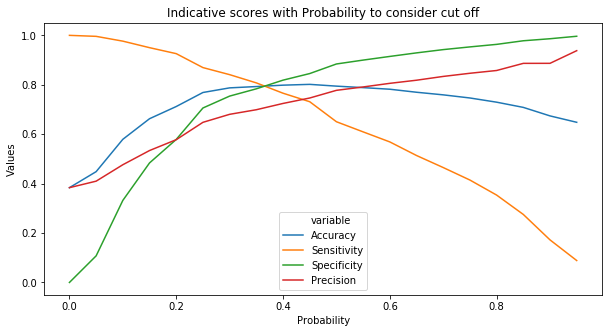

,Prob,Accuracy,Sensitivity,Specificity,Precision,TP,FN,TN,FP
0,0.00,0.383610,1.000000,0.000000,0.383610,2729.0,0.0,0.0,4385.0
1,0.05,0.448412,0.995969,0.107640,0.409893,2718.0,11.0,472.0,3913.0
2,0.10,0.579280,0.976548,0.332041,0.476403,2665.0,64.0,1456.0,2929.0
3,0.15,0.662637,0.950165,0.483694,0.533869,2593.0,136.0,2121.0,2264.0
4,0.20,0.711976,0.925980,0.578791,0.577732,2527.0,202.0,2538.0,1847.0
5,0.25,0.768766,0.869549,0.706043,0.648007,2373.0,356.0,3096.0,1289.0
6,0.30,0.787461,0.840967,0.754162,0.680403,2295.0,434.0,3307.0,1078.0
7,0.35,0.792803,0.807622,0.783580,0.699017,2204.0,525.0,3436.0,949.0
8,0.40,0.798426,0.765848,0.818700,0.724437,2090.0,639.0,3590.0,795.0
9,0.45,0.801659,0.731403,0.845382,0.746447,1996.0,733.0,3707.0,678.0


In [192]:
# This  block of the code is to calculate the stats like Accuracy /  Sensitivity  / Specificity at various point of probablities and henceforth to deside the cut of probability. 


lm = LogisticRegression()
fit1 = lm.fit(X_train[final_columns],y_train)
y_pred_prob = fit1.predict_proba(X_train[final_columns])

measures = pd.DataFrame(columns=["Prob","Accuracy","Sensitivity","Specificity","Precision","TP","FN","TN","FP"])
#measures["cutof"] =np.arange(0,1,0.05)
for i in np.arange(0,1,0.05):
    _altered_y = [1 if j >=i else 0 for j in y_pred_prob[:,1]]
    mat = confusion_matrix(y_train,_altered_y)
    tn, fp, fn, tp = mat.ravel()
    _accracy = (tn+tp) / (tn+tp+fn+fp)
    _sensitivity = tp / (tp+fn)
    _specificity =tn / (tn+fp)
    _precision = tp / (fp + tp)
    
    _item={"Prob":i,"Accuracy":_accracy,"Sensitivity":_sensitivity,"Specificity":_specificity,"Precision":_precision,"TP":tp,"FN":fn,"TN":tn,"FP":fp}
    measures=measures.append(_item,ignore_index=True )
    #print(_item)
   

_temp =pd.melt( measures,id_vars=["Prob"],value_vars=["Accuracy","Sensitivity","Specificity","Precision"])

plt.figure(figsize=(10,5))
sns.lineplot(data = _temp,x="Prob",y="value",hue="variable")
plt.title("Indicative scores with Probability to consider cut off")
plt.xlabel("Probability")
plt.ylabel("Values")
plt.show()

measures

## Review Remaks 

- based on the above grpah, it is indicates that at the level of 0.35 and 0.4 indicating better results balancing between TP and FP.
- Table also indicating same thing

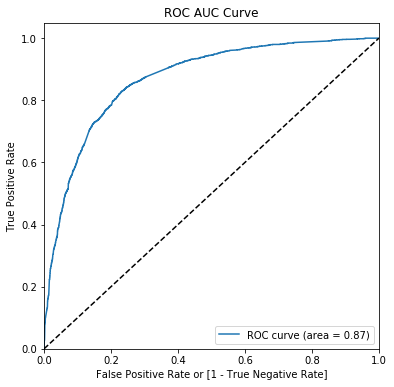

In [193]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

def draw_roc( actual, probs ):
    fpr, tpr, thresholds = roc_curve( actual, probs,
                                              drop_intermediate = False )
    auc_score = roc_auc_score( actual, probs )
    plt.figure(figsize=(6, 6))
    plt.plot( fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score )
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('ROC AUC Curve')
    plt.legend(loc="lower right")
    plt.show()

    return #fpr, tpr, thresholds

draw_roc(y_train, y_pred_prob[:,1])

### Review Summary 

- By Seeing the model it indicating that 35% of poobability seems good with the sensitivity score of 81% (that means we are able to sucessfully predict 80% of potential converters)
at the same level specficity levels also maintained at the good amount of 78%. 

- ROC AUC curve also indicating around 0.87 which means we can conculde that model is good

### Model testing with the test data set

In [194]:
# Model testing 

#scalling neumarical features in the x_test 

X_test[Continuous_values]=scaler.transform(X_test[Continuous_values])

In [195]:
# testing model 

ytest_pred_prob = fit1.predict_proba(X_test[final_columns])

ytest_perd =[1 if i >=0.35 else 0 for i in ytest_pred_prob[:,1]]

mat = confusion_matrix(y_test,ytest_perd)
tn, fp, fn, tp = mat.ravel()

printmd(f"## Accuracy on Training Data Set  { ( (tn+tp) / (tn+tp+fn+fp) *100).round(2)}")
printmd(f"## Sensitivity on Training Data Set  { ( tp / (tp+fn) *100).round(2)}")
printmd(f"## Specificity on Training Data Set  { ( tn / (tn+fp) *100).round(2)}")
printmd(f"## Precision on Training Data Set  { (tp / (fp + tp) *100).round(2)}")


## Accuracy on Training Data Set  78.74

## Sensitivity on Training Data Set  78.97

## Specificity on Training Data Set  78.59

## Precision on Training Data Set  70.34

In [214]:
#Lead Scores for each Test Data Set
results_test=pd.DataFrame(Original_data.loc[Original_data.index.isin(X_test.index),["Lead Number"]])
results_test["Lead_Score"] = ytest_pred_prob[:,1] *100
results_test["Lead_Score"] = round(results_test["Lead_Score"])
results_test["Lead_Score"]=results_test["Lead_Score"].astype(int)
results_test

,Lead Number,Lead_Score
3,660719,63
10,660608,93
12,660562,15
16,660540,7
21,660478,90
22,660471,65
25,660447,56
30,660402,13
41,660222,13
43,660203,40


# Review Remaks

Eventhough Test data set senstivity is indicating 79%. same model performed on the training data set with the senstivity of 81% which is indicates that model is not over fit and this difference is acceptable region. 

all other indicators on the test data set is such as (accuracy /  Sensitivity /  Specificity /  Precesion) are very close to the values derived from the Training Data Set model values.

- Based on the above justification we can conclude that model is not overfit and satsfcatory to give a sucess ratio of 80% as per the CEO Demand.

Model Accuracy on Train :- <b> 79.28% </b> and test data set : <b> 78.74% </b> <br>
Model Sensitivity on Train :- <b> 80.76% </b> and test data set : <b> 78.97% </b> <br>
Model Specificity on Train :- <b> 78.35% </b> and test data set : <b> 78.59% </b>

## <Font color="green" > Summary  </font>

### The following steps have been used to arrive at the final solution:

- Exploratory data analysis was carried out. There were total 9340 rows x 37 columns. We carried out checks for duplicate data and null values. There were no duplicate data but around <b> 13 variables had missing values of > 20% and around 4 variables had approx. 2% missing values </b>;
- The data was well balanced data with <b>39%  conversion rate </b> and 61% non-conversion rate to carry out the analysis. As there were a lot of data with missing values, we proceeded to individually check the importance of the variables, in terms of whether to retain the same or drop them from analysis;
- Out of the 17 columns with missing values which we analysed, we dropped 12 columns. The reason for dropping the same was either insufficient information or data not meeting the objectives of the analysis. We also dropped those cases, where imputation of data with maximum occurrence may not have sufficiently explained the variance with target variable;
- Then, we performed Univariate analysis and performed following functions:
- Outlier analysis was carried out;
- Grouping of homogenous data in one category was done;
- If the data was not adding value, we dropped data at this stage as well;
- Dummy variables has been created for categorical data with two levels;
- One hot encoding was performed for data with more than two levels.
- We then split the data into train and test data set and performed scaling of numerical variables to remove biasness. We also checked for correlation between the dataset and inferred that some of the variables exhibited high level of correlation, however, we ignored the same;
- We now began the modelling part. Using RFE, we fixed the output number of variable to 20. Then we ran the GLM for logistic regression and VIF which quantifies the severity of multicollinearity. We interpreted the results of the GLM model with respect to p-values and also looked at the VIF score. We followed the principle of first handling variables with high p-values and then high VIF scores. We re-ran the model and again did the analysis, until the model gave us acceptable p-values (<5%) and VIF score of less than 5;
- Once the final output variables were selected, we computed the odds and probability of all predictor variables. This step gave us the relative importance of predictor variables, focussing on which would help in higher probability of converting leads into results; 

- We have compare the probability of choice along with the all indicators.
- we have desided to take the cut of probability at 0.35 to statsfy the CEO interest to target 80% of lead's with intention to sucessfully eliminate high potential the FP identified cases to save sale staff efforts.
- We also checked the performance of the model using accuracy, sensitivity, specificity and precision. High values on all the four counts reflected the accuracy of our model;
- Lastly, we conducted the testing of our model on the test data set and similar high score of model performance validated the steps adopted by us, including the ballpark target set up by the CEO.

